In [1]:
import torch
import dgl
import yaml

print("torch:", torch.__version__)
print("dgl:", dgl.__version__)
print("cuda:", torch.cuda.is_available())


torch: 2.1.0+cu121
dgl: 2.1.0+cu121
cuda: True


/home/yyyy/anaconda3/envs/gnn/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pandas as pd

# 假设数据加载如下
df_pos = pd.read_csv('/home/yyyy/codework/GARplus/GNN/code/data/protein_protein.csv')
df_neg = pd.read_csv('/home/yyyy/codework/GARplus/GNN/code/data/neg_protein_protein.csv')

# =======================================================
# 关键步骤：规范化边 (处理无向性)
# =======================================================
# PPI通常是无向图，(src=1, dst=2) 和 (src=2, dst=1) 是同一条边。
# 为了准确统计，我们需要将每行的 src 和 dst 排序，确保小的在前，大的在后。

def standardize_edges(df):
    # 创建副本以免修改原始数据
    df_sorted = df.copy()
    # 逐行排序 src 和 dst
    # axis=1 表示按行操作，min取两者中小值作为src，max取大值作为dst
    df_sorted['u'] = df[['src', 'dst']].min(axis=1)
    df_sorted['v'] = df[['src', 'dst']].max(axis=1)
    return df_sorted[['u', 'v']] # 只保留排序后的列用于对比

# 1. 对两个表都进行规范化
pos_edges = standardize_edges(df_pos)
neg_edges = standardize_edges(df_neg)

# 2. 检查 neg 中的边是否在 pos 中出现
# 使用 merge (inner join) 来求交集
overlap = pd.merge(neg_edges, pos_edges, on=['u', 'v'], how='inner')

# =======================================================
# 结果输出
# =======================================================

# 统计数量
num_overlap = len(overlap)
total_neg = len(df_neg)
ratio = (num_overlap / total_neg) * 100

print(f"总负样本边数: {total_neg}")
print(f"在正样本中存在的数量 (False Negatives): {num_overlap}")
print(f"重复比例: {ratio:.4f}%")

if num_overlap > 0:
    print("\n重复的边示例 (前5条):")
    print(overlap.head())
    
    # 如果你想把这些重复的坏边保存下来：
    # overlap.to_csv('overlapped_edges.csv', index=False)

总负样本边数: 1426
在正样本中存在的数量 (False Negatives): 314
重复比例: 22.0196%

重复的边示例 (前5条):
        u       v
0  157703  161541
1  181378  191151
2  153998  160721
3  157849  158831
4  153905  156446


# 根据Index把LLM生成的正边和confirmed-negative拼接起来

In [1]:
import pandas as pd
import numpy as np
import os
from pathlib import Path

def generate_fixed_pos_ratio_datasets(
    pos_file_path, 
    neg_file_path, 
    seed=42
):
    # 设置随机种子
    np.random.seed(seed)
    
    print(f"===== 1. 数据加载与预处理 =====")
    
    # ---------------------------
    # 1. 加载负样本 (作为基准池)
    # ---------------------------
    print(f"读取负样本: {neg_file_path}")
    df_neg_pool = pd.read_csv(neg_file_path)
    
    # 标准化列名
    if 'src' not in df_neg_pool.columns: # 假设只有两列
        df_neg_pool = df_neg_pool.iloc[:, :2]
        df_neg_pool.columns = ['src', 'dst']
        
    df_neg_pool = df_neg_pool[['src', 'dst']]
    df_neg_pool['src'] = df_neg_pool['src'].astype(int)
    df_neg_pool['dst'] = df_neg_pool['dst'].astype(int)
    df_neg_pool['label'] = 2  # 负样本 Label
    
    total_neg_available = len(df_neg_pool)
    print(f"-> 原始负样本池大小: {total_neg_available}")

    # ---------------------------
    # 2. 加载正样本 (作为候选池)
    # ---------------------------
    print(f"读取正样本: {pos_file_path}")
    df_pos_all = pd.read_csv(pos_file_path)
    
    # 筛选 type=positive 并重命名列
    df_pos_cand = df_pos_all[df_pos_all['type'] == 'positive'].copy()
    df_pos_cand = df_pos_cand.rename(columns={'index_A': 'src', 'index_B': 'dst'})
    df_pos_cand = df_pos_cand[['src', 'dst']]
    df_pos_cand['src'] = df_pos_cand['src'].astype(int)
    df_pos_cand['dst'] = df_pos_cand['dst'].astype(int)
    df_pos_cand['label'] = 1 # 正样本 Label
    
    print(f"-> 原始正样本候选数量: {len(df_pos_cand)}")

    # ---------------------------
    # 3. 冲突清洗 (关键步骤)
    # ---------------------------
    # 既然负样本池是基准，如果正样本里有跟负样本重复的边，必须剔除正样本
    print("正在清洗正样本 (剔除与负样本池冲突的边)...")
    
    # 构建负样本查找集 (处理无向边)
    neg_edge_set = set()
    for u, v in zip(df_neg_pool['src'], df_neg_pool['dst']):
        neg_edge_set.add(tuple(sorted((u, v))))
        
    # 筛选不冲突的正样本
    # 使用列表推导式比 iterrows 快
    keep_mask = [tuple(sorted((u, v))) not in neg_edge_set for u, v in zip(df_pos_cand['src'], df_pos_cand['dst'])]
    pos_pool = df_pos_cand[keep_mask].copy()
    
    print(f"-> 冲突剔除数量: {len(df_pos_cand) - len(pos_pool)}")
    print(f"-> 最终可用正样本池: {len(pos_pool)}")

    # ==========================================
    # 4. 核心逻辑实现 (按照你提供的思路)
    # ==========================================
    print(f"\n===== 数据集生成配置 =====")
    
    # 目标：正边是原始负边的10倍
    fixed_pos_num = total_neg_available * 10 
    print(f"原始负边池大小 (total_neg_available): {total_neg_available}")
    print(f"设定固定正边数量 (fixed_pos_num): {fixed_pos_num}")

    # 检查正边是否足够
    if len(pos_pool) < fixed_pos_num:
        print(f"[警告] 正边池数量 ({len(pos_pool)}) 不足 {fixed_pos_num}，将使用所有可用正边。")
        fixed_pos_num = len(pos_pool)

    # [步骤 A] 一次性固定所有数据集使用的正边
    # 保证不同 ratios 之间，正边完全一样
    pos_fixed_sample = pos_pool.sample(n=fixed_pos_num, replace=False, random_state=seed)
    print(f"-> 已锁定正样本集，数量: {len(pos_fixed_sample)}")

    # 准备保存目录
    save_dir = Path("data_signed_ratios")
    save_dir.mkdir(parents=True, exist_ok=True)
    
    # 定义不平衡比例 ratios (Pos : Neg)
    # 10 代表 Pos:Neg = 10:1 (负样本最多)
    # 60 代表 Pos:Neg = 60:1 (负样本最少)
    ratios = [10, 20, 30, 40, 50, 60]

    summary = []

    for r in ratios:
        # [步骤 B] 计算当前比例下需要的负边数量
        # 公式: Neg_Need = Fixed_Pos / Ratio
        neg_need = int(fixed_pos_num / r)
        
        # 边界检查
        if neg_need > len(df_neg_pool):
            neg_need = len(df_neg_pool)
            print(f"Ratio {r}x 需要负样本 {neg_need}，但这超过了池子上限，取最大值。")

        # [步骤 C] 随机抽取负边
        # 每次都从原始全量负样本池中重新抽，保证随机性 (且肯定不含冲突，因为前面清洗过正样本了)
        neg_sample = df_neg_pool.sample(n=neg_need, replace=False, random_state=seed)

        # [步骤 D] 合并
        cur_edges = pd.concat([pos_fixed_sample, neg_sample], axis=0)
        
        # [步骤 E] 打乱顺序
        cur_edges = cur_edges.sample(frac=1.0, random_state=seed).reset_index(drop=True)
        
        # 添加关系类型列 (DGL/PyG 可能需要)
        cur_edges["rel"] = "protein_protein"

        # 保存
        filename = f"edges_ratio{r}x.csv"
        edges_path = save_dir / filename
        
        # 严格按照列顺序保存
        cur_edges[["src", "dst", "rel", "label"]].to_csv(edges_path, index=False)

        print(f"[生成完成] Ratio {r}x | Pos: {len(pos_fixed_sample)} | Neg: {neg_need} | Total: {len(cur_edges)}")

        summary.append({
            "ratio_label": f"{r}x",
            "imbalance_ratio": f"{r}:1",
            "pos_count": len(pos_fixed_sample),
            "neg_count": neg_need,
            "neg_fraction": f"{neg_need/total_neg_available:.2%}",
            "file_name": filename
        })

    # 输出汇总表
    print("\n===== 数据集统计汇总 =====")
    summary_df = pd.DataFrame(summary)
    print(summary_df)
    
    # 保存汇总信息到 CSV 方便查阅
    # summary_df.to_csv(save_dir / "dataset_summary.csv", index=False)

# ==========================
# 运行
# ==========================
pos_file = '/home/yyyy/codework/GARplus/DiGress/DiGress-main/data/PPI/raw/protein_protein_with_type.csv'
neg_file = '/home/yyyy/codework/GARplus/GNN/code/data/neg_protein_protein.csv' # 确保此文件存在
#TODO 构建edges.csv和node.csv文件
generate_fixed_pos_ratio_datasets(pos_file, neg_file)

===== 1. 数据加载与预处理 =====
读取负样本: /home/yyyy/codework/GARplus/GNN/code/data/neg_protein_protein.csv
-> 原始负样本池大小: 1426
读取正样本: /home/yyyy/codework/GARplus/DiGress/DiGress-main/data/PPI/raw/protein_protein_with_type.csv
-> 原始正样本候选数量: 681684
正在清洗正样本 (剔除与负样本池冲突的边)...
-> 冲突剔除数量: 292
-> 最终可用正样本池: 681392

===== 数据集生成配置 =====
原始负边池大小 (total_neg_available): 1426
设定固定正边数量 (fixed_pos_num): 14260
-> 已锁定正样本集，数量: 14260
[生成完成] Ratio 10x | Pos: 14260 | Neg: 1426 | Total: 15686
[生成完成] Ratio 20x | Pos: 14260 | Neg: 713 | Total: 14973
[生成完成] Ratio 30x | Pos: 14260 | Neg: 475 | Total: 14735
[生成完成] Ratio 40x | Pos: 14260 | Neg: 356 | Total: 14616
[生成完成] Ratio 50x | Pos: 14260 | Neg: 285 | Total: 14545
[生成完成] Ratio 60x | Pos: 14260 | Neg: 237 | Total: 14497

===== 数据集统计汇总 =====
  ratio_label imbalance_ratio  pos_count  neg_count neg_fraction  \
0         10x            10:1      14260       1426      100.00%   
1         20x            20:1      14260        713       50.00%   
2         30x            30:1    

In [2]:
all_node = pd.read_csv("/home/yyyy/codework/GARplus/GNN/code/data/node.csv")
# 筛选 node_type 列等于 'protein' 的所有行
protein_node = all_node[all_node['node_type'] == 'protein']
print(protein_node.shape[0])
protein_node.to_csv("/home/yyyy/codework/GARplus/GNN/code/data_signed_ratios/node.csv")

207016


In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import dgl
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score
from sklearn.model_selection import train_test_split

# ==========================
# 1. 图加载
# ==========================

def load_graph(node_csv, edge_csv, device="cpu"):
    nodes = pd.read_csv(node_csv)
    num_nodes = len(nodes)

    edges = pd.read_csv(edge_csv)
    src = torch.tensor(edges["src"].values, dtype=torch.int64)
    dst = torch.tensor(edges["dst"].values, dtype=torch.int64)

    g = dgl.graph((src, dst), num_nodes=num_nodes)
    g = dgl.add_edges(g, dst, src)
    g = dgl.add_self_loop(g)


    return g.to(device), edges, num_nodes


# ==========================
# 2. 构造训练样本
# ==========================
#TODO  这里采样的无边不一定是真的无边
def sample_non_edges(num_nodes, edges, num_samples):
    exist = set()
    for s, d in zip(edges["src"], edges["dst"]):
        exist.add((s, d))
        exist.add((d, s))  # 无向视角
    samples = set()
    print(len(exist))
    while len(samples) < num_samples:
        s = np.random.randint(0, num_nodes)
        d = np.random.randint(0, num_nodes)
        if s != d and (s, d) not in exist:
            samples.add((s, d))
    print(len(samples))
    return samples


def build_samples(g, edges, num_nodes):
    pos = edges[edges["label"] == 1]
    neg = edges[edges["label"] == 2]

    src, dst, label = [], [], []

    for _, r in pos.iterrows():
        src.append(r.src)
        dst.append(r.dst)
        label.append(1)

    for _, r in neg.iterrows():
        src.append(r.src)
        dst.append(r.dst)
        label.append(2)

    # 采样无边
    non_edges = sample_non_edges(num_nodes, edges, len(pos))
    for s, d in non_edges:
        src.append(s)
        dst.append(d)
        label.append(0)

    return torch.tensor(src), torch.tensor(dst), torch.tensor(label)


# ==========================
# Dataset
# ==========================

class EdgeDataset(Dataset):
    def __init__(self, src, dst, label):
        self.src = src
        self.dst = dst
        self.label = label

    def __len__(self):
        return len(self.label)

    def __getitem__(self, idx):
        return self.src[idx], self.dst[idx], self.label[idx]


# ==========================
# RGCN + 三分类 Decoder
# ==========================

from dgl.nn import GraphConv

class RGCNEncoder(nn.Module):
    def __init__(self, in_feats=16, h_feats=32, out_feats=32):
        super().__init__()
        self.layer1 = GraphConv(in_feats, h_feats)
        self.layer2 = GraphConv(h_feats, out_feats)

    def forward(self, g, feat):
        h = torch.relu(self.layer1(g, feat))
        h = self.layer2(g, h)
        return h

import torch.nn.functional as F
from dgl.nn.pytorch import GATConv


class GATEncoder(nn.Module):
    def __init__(self, in_dim=16, hidden_dim=32, out_dim=32, num_heads=4, dropout=0.2):
        super().__init__()
        self.dropout = dropout

        # 第一层：in_dim → hidden_dim
        self.layer1 = GATConv(
            in_dim,
            hidden_dim,
            num_heads=num_heads,
            feat_drop=0,
            attn_drop=0
        )

        # 第二层：hidden_dim → out_dim
        # 注意：上一层会输出 hidden_dim * num_heads
        self.layer2 = GATConv(
            hidden_dim,
            out_dim,
            num_heads=1,
            feat_drop=dropout,
            attn_drop=dropout
        )

    def forward(self, g, feat):
        # Layer1
        h = self.layer1(g, feat)       # shape: [N, num_heads, hidden_dim]
        h = h.mean(dim=1)              # 多头求平均 → [N, hidden_dim]
        h = F.elu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)

        # Layer2
        h = self.layer2(g, h)          # shape: [N, 1, out_dim]
        h = h.squeeze(1)               # → [N, out_dim]
        return h

class EdgeClassifier(nn.Module):
    def __init__(self, in_dim, hidden_dim=64, num_classes=3):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, emb, src, dst):
        h = torch.cat([emb[src], emb[dst]], dim=1)
        return self.mlp(h)


class RGCNModel(nn.Module):
    def __init__(self, in_dim=16):
        super().__init__()
        self.encoder = RGCNEncoder(in_dim, 32, 32)
        self.decoder = EdgeClassifier(32, 64, 3)

    def forward(self, g, feat, src, dst):
        emb = self.encoder(g, feat)
        return self.decoder(emb, src, dst)

class GATModel(nn.Module):
    def __init__(self, in_dim=16, hidden_dim=32, out_dim=32, num_heads=4, dropout=0.2):
        super().__init__()
        self.encoder = GATEncoder(
            in_dim=in_dim,
            hidden_dim=hidden_dim,
            out_dim=out_dim,
            num_heads=num_heads,
            dropout=dropout
        )
        self.decoder = EdgeClassifier(out_dim)

    def forward(self, g, feat, src, dst):
        emb = self.encoder(g, feat)
        return self.decoder(emb, src, dst)
# ==========================
# Train & Eval
# ==========================
def multi_class_pr_auc(labels, probs, num_classes=3):
    prcs = []
    for c in range(num_classes):
        y_true = (labels == c).astype(int)
        y_score = probs[:, c]

        if y_true.sum() == 0:   # 跳过没有真实样本的类别
            continue

        prc = average_precision_score(y_true, y_score)
        prcs.append(prc)

    return np.mean(prcs) if len(prcs) > 0 else 0.0

# ==========================
# 1. 改进后的采样与数据准备
# ==========================

def sample_non_edges_fixed(num_nodes, forbidden_src, forbidden_dst, num_samples):
    """
    采样无边 (Label 0)。
    forbidden_src/dst: 必须包含所有真实存在的边 (Label 1 和 Label 2)，防止生成的 0 与 2 冲突。
    """
    exist = set()
    for s, d in zip(forbidden_src, forbidden_dst):
        if s > d: s, d = d, s # 统一存为 (min, max) 处理无向冲突
        exist.add((s, d))
    
    samples = set()
    # 简单的随机采样
    # 如果图非常稠密，这里建议加一个最大尝试次数防止死循环，但在一般稀疏图没问题
    while len(samples) < num_samples:
        s = np.random.randint(0, num_nodes)
        d = np.random.randint(0, num_nodes)
        
        if s == d: continue
        
        k = (s, d) if s < d else (d, s)
        if k not in exist:
            samples.add((s, d)) 
            
    return list(samples)

def prepare_data(node_csv, edge_csv):
    print("正在准备数据...")
    
    # 1. 读取基础数据
    nodes = pd.read_csv(node_csv)
    num_nodes = len(nodes)
    edges = pd.read_csv(edge_csv)
    
    # 2. 分离不同 Label 的边
    # 假设 CSV 中 label 列明确为 1 和 2
    df_pos = edges[edges['label'] == 1]  # Pos 边
    df_neg = edges[edges['label'] == 2]  # Neg 边 (真实存在的另一种关系)
    
    print(f"原始数据统计: Label 1 (Pos) = {len(df_pos)}, Label 2 (Neg) = {len(df_neg)}")

    # 3. 确定采样数量
    # 您的要求：Label 0 的数量 == Label 1 的数量
    num_samples_L0 = len(df_pos)
    
    # 4. 生成 Label 0 (无边)
    # 注意：forbidden 必须传入所有真实边 (Label 1 + Label 2)，防止把 Label 2 误当成 Label 0
    all_real_src = edges["src"].values
    all_real_dst = edges["dst"].values
    
    generated_L0_pairs = sample_non_edges_fixed(
        num_nodes, 
        forbidden_src=all_real_src, 
        forbidden_dst=all_real_dst, 
        num_samples=num_samples_L0
    )
    
    # 构造 Label 0 的数组
    src_L0 = np.array([p[0] for p in generated_L0_pairs])
    dst_L0 = np.array([p[1] for p in generated_L0_pairs])
    lbl_L0 = np.zeros(len(generated_L0_pairs), dtype=int)
    
    # 5. 合并所有数据 (Label 1 + Label 2 + Label 0)
    all_src = np.concatenate([edges["src"].values, src_L0])
    all_dst = np.concatenate([edges["dst"].values, dst_L0])
    all_lbl = np.concatenate([edges["label"].values, lbl_L0])
    
    print(f"采样后总数据量: {len(all_lbl)} (其中 Label 0: {len(lbl_L0)})")
    
    # 6. 划分训练/验证集
    all_idx = np.arange(len(all_lbl))
    train_idx, val_idx = train_test_split(all_idx, test_size=0.2, shuffle=True, random_state=42)
    
    # =====================================================
    # 7. 构建 GNN 背景图 (防泄露)
    # =====================================================
    # 规则：图里只能包含 "训练集" 里的 "真实边" (Label 1 和 Label 2)
    
    is_in_train = np.isin(all_idx, train_idx) 
    is_real_edge = (all_lbl != 0) # 只有 Label 1 和 2 能进图
    
    graph_edges_mask = is_in_train & is_real_edge
    
    g_src = all_src[graph_edges_mask]
    g_dst = all_dst[graph_edges_mask]
    
    # 构建 DGL 图
    g = dgl.graph((g_src, g_dst), num_nodes=num_nodes)
    g = dgl.add_edges(g, g_dst, g_src) # 添加反向边 (通常做法)
    g = dgl.add_self_loop(g)
    
    # 8. 封装 Dataset
    train_dataset = EdgeDataset(all_src[train_idx], all_dst[train_idx], all_lbl[train_idx])
    val_dataset = EdgeDataset(all_src[val_idx], all_dst[val_idx], all_lbl[val_idx])
    
    return g, train_dataset, val_dataset, num_nodes




def evaluate_unbalance(model, loader, g, feat, device):
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []

    criterion = nn.CrossEntropyLoss()
    total_loss = 0

    with torch.no_grad():
        for s, d, y in loader:
            s, d, y = s.to(device), d.to(device), y.to(device)

            logits = model(g, feat, s, d)
            loss = criterion(logits, y)
            total_loss += loss.item()

            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_labels.extend(y.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    labels = np.array(all_labels)
    preds = np.array(all_preds)
    probs = np.array(all_probs)

    # 基础指标
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="macro")
    auc = roc_auc_score(labels, probs, multi_class="ovr")
    prc = multi_class_pr_auc(labels, probs, num_classes=3)
    pre = precision_score(labels, preds, average="macro", zero_division=0)
    rec = recall_score(labels, preds, average="macro", zero_division=0)
    # [关键修改] 获取每个类别的详细 Recall
    # labels=[0, 1, 2] 确保即使某个类没预测出来也不会报错
    rec_per_class = recall_score(labels, preds, average=None, labels=[0, 1, 2], zero_division=0)
    pre_per_class = precision_score(labels, preds, average=None, labels=[0, 1, 2], zero_division=0)
    
    # 提取 Label 2 (Negative) 的指标
    rec_label2 = rec_per_class[2]
    pre_label2 = pre_per_class[2]

    # 返回增加了 rec_label2
    return total_loss, acc, f1, auc, prc, pre,rec, rec_label2, pre_label2



def train_model_unbalance(node_csv, edge_csv):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    # 1. 准备数据
    g, train_ds, val_ds, num_nodes = prepare_data(node_csv, edge_csv)
    g = g.to(device)

    # 2. Embedding
    node_emb = nn.Embedding(num_nodes, 16).to(device)
    
    # 3. DataLoader
    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=256, shuffle=False)

    # 4. 模型 (RGCN 或 GAT)
    model = GATModel(in_dim=16, hidden_dim=32, out_dim=32, num_heads=4).to(device)
    # model = RGCNModel(in_dim=16).to(device)
    optimizer = optim.Adam(list(model.parameters()) + list(node_emb.parameters()), lr=1e-3)
    
    # [重要] 实验要求 Loss 不加权，以观察不平衡的影响
    criterion = nn.CrossEntropyLoss()

    # 记录最后一次的结果
    final_metrics = {}

    for epoch in range(20): # 20个epoch通常足够观察趋势
        model.train()
        total_loss = 0
        
        # 简化 tqdm 显示
        epoch_iter = tqdm(train_loader, desc=f"Epoch {epoch:02d}", ncols=80, leave=False)
        
        for s, d, y in epoch_iter:
            s, d, y = s.to(device), d.to(device), y.to(device)
            logits = model(g, node_emb.weight, s, d)
            loss = criterion(logits, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        # 验证
        val_loss, acc, f1, auc, prc, pre, rec,rec2, pre2 = evaluate_unbalance(model, val_loader, g, node_emb.weight, device)

    # ====== 修改 1：打印所有指标 ======
    # 为了防止一行太长，这里使用了分行写法，保留了4位小数
    print(f"[Ep {epoch}] Val_Loss={val_loss:.4f} | Acc={acc:.4f} | F1={f1:.4f} | "
        f"AUC={auc:.4f} | AP={prc:.4f} | Neg_Rec={rec2:.4f} | Neg_Pre={pre2:.4f}")

    # ====== 修改 2：返回包含所有指标的字典 ======
    final_metrics = {
        "loss": val_loss,
        "acc": acc,
        "macro_f1": f1,
        "auc": auc,
        "ap": prc,             # Average Precision (PRC)
        "neg_recall": rec2,    # Label 2 (负样本) 召回率
        "neg_precision": pre2,  # Label 2 (负样本) 精确率
        "pre": pre,
        "rec": rec
    }
    return model, final_metrics

def evaluate(model, loader, g, feat, device):
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []

    criterion = nn.CrossEntropyLoss()
    total_loss = 0

    with torch.no_grad():
        for s, d, y in loader:
            s, d, y = s.to(device), d.to(device), y.to(device)

            logits = model(g, feat, s, d)
            loss = criterion(logits, y)
            total_loss += loss.item()

            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_labels.extend(y.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    labels = np.array(all_labels)
    preds = np.array(all_preds)
    probs = np.array(all_probs)

    acc = accuracy_score(labels, preds)
    pre = precision_score(labels, preds, average="macro", zero_division=0)
    rec = recall_score(labels, preds, average="macro", zero_division=0)
    f1 = f1_score(labels, preds, average="macro")

    # AUC（多分类用 OvR）
    auc = roc_auc_score(labels, probs, multi_class="ovr")
    prc = multi_class_pr_auc(labels, probs, num_classes=3)

    return total_loss, acc, pre, rec, f1, auc, prc


# ==========================
# 主函数
# ==========================

def train_model(node_csv, edge_csv):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    # 1. 准备数据 (数量逻辑已修复)
    g, train_ds, val_ds, num_nodes = prepare_data(node_csv, edge_csv)
    g = g.to(device)

    # 2. 可学习的 Embedding
    node_emb = nn.Embedding(num_nodes, 16).to(device)
    
    # 3. DataLoader
    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=256, shuffle=False)

    # 4. 模型
    model = GATModel(in_dim=16, hidden_dim=32, out_dim=32, num_heads=4).to(device)
    # model = RGCNModel(in_dim=16).to(device)
    optimizer = optim.Adam(list(model.parameters()) + list(node_emb.parameters()), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    # 5. Loop
    prc_list = []
    auc_list = []
    f1_list = []
    train_loss_list = []
    val_loss_list = []
    
    for epoch in range(20):
        model.train()
        total_loss = 0
        
        epoch_iter = tqdm(train_loader, desc=f"Epoch {epoch:02d}", ncols=100)
        
        for s, d, y in epoch_iter:
            s, d, y = s.to(device), d.to(device), y.to(device)
            
            logits = model(g, node_emb.weight, s, d)
            loss = criterion(logits, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            epoch_iter.set_postfix(loss=f"{loss.item():.4f}")

        # Eval
        val_loss, acc, pre, rec, f1, auc, prc = evaluate(model, val_loader, g, node_emb.weight, device)
        prc_list.append(prc)
        auc_list.append(auc)
        f1_list.append(f1)
        train_loss_list.append(total_loss)
        val_loss_list.append(val_loss)

        print(
            f"[Epoch {epoch:02d}] "
            f"Train Loss={total_loss:.4f} | "
            f"Val Loss={val_loss:.4f} | "
            f"Acc={acc:.4f} | Pre={pre:.4f} | Rec={rec:.4f} | "
            f"F1={f1:.4f} | AUC={auc:.4f} | PRC={prc:.4f}"
        )

    print("训练完成！")
    results = {
        "train_loss": train_loss_list,
        "val_loss": val_loss_list,
        "prc": prc_list,
        "auc": auc_list,
        "f1": f1_list
    }
    return model,results



/home/yyyy/anaconda3/envs/gnn/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import torch
import numpy as np
import random
import dgl
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

def reset_seed(seed):
    np.random.seed(seed)  # 设置NumPy随机种子
    random.seed(seed)  # 设置Python随机种子

    torch.manual_seed(seed)
    dgl.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # 多GPU情况

    # torch.backends.cudnn.deterministic = True

seed = 42
reset_seed(seed)

# Added negatives

In [5]:
reset_seed(seed)
print("正在处理：", "/home/yyyy/codework/GARplus/GNN/code/data_updated/edge_update.csv",)
model,cur_results = train_model("/home/yyyy/codework/GARplus/GNN/code/data_updated/node.csv", "/home/yyyy/codework/GARplus/GNN/code/data_updated/edge_update.csv")
print(cur_results)
print("=============================================================================")

正在处理： /home/yyyy/codework/GARplus/GNN/code/data_updated/edge_update.csv
正在准备数据...
原始数据统计: Label 1 (Pos) = 685559, Label 2 (Neg) = 10983
采样后总数据量: 1382101 (其中 Label 0: 685559)


Epoch 00: 100%|█████████████████████████████████| 17277/17277 [02:14<00:00, 128.49it/s, loss=0.2959]


[Epoch 00] Train Loss=6734.3460 | Val Loss=462.4027 | Acc=0.8142 | Pre=0.8030 | Rec=0.6498 | F1=0.6887 | AUC=0.9303 | PRC=0.7671


Epoch 01: 100%|█████████████████████████████████| 17277/17277 [02:11<00:00, 130.97it/s, loss=0.1805]


[Epoch 01] Train Loss=5500.4781 | Val Loss=373.3324 | Acc=0.8578 | Pre=0.7724 | Rec=0.7784 | F1=0.7744 | AUC=0.9479 | PRC=0.8304


...

[Epoch 17] Train Loss=4175.7340 | Val Loss=321.7061 | Acc=0.8821 | Pre=0.8421 | Rec=0.7754 | F1=0.8033 | AUC=0.9629 | PRC=0.8733


Epoch 18: 100%|█████████████████████████████████| 17277/17277 [02:14<00:00, 128.12it/s, loss=0.3470]


[Epoch 18] Train Loss=4162.9375 | Val Loss=319.6970 | Acc=0.8830 | Pre=0.8311 | Rec=0.8079 | F1=0.8187 | AUC=0.9633 | PRC=0.8794


Epoch 19: 100%|█████████████████████████████████| 17277/17277 [02:16<00:00, 126.33it/s, loss=0.2432]


[Epoch 19] Train Loss=4141.8360 | Val Loss=324.1527 | Acc=0.8809 | Pre=0.8602 | Rec=0.7664 | F1=0.8031 | AUC=0.9626 | PRC=0.8777
训练完成！
{'train_loss': [6734.346001803875, 5500.478099107742, 5149.372123070061, 4957.209173135459, 4820.667921371758, 4705.434025719762, 4629.121860861778, 4557.647487446666, 4501.588297296315, 4441.3027918078005, 4395.254830002785, 4365.333824895322, 4323.099011767656, 4290.432022500783, 4266.724802225828, 4233.697186481208, 4209.9744760766625, 4175.733950033784, 4162.937485106289, 4141.83599871397], 'val_loss': [462.4026908874512, 373.33239959180355, 381.2492921203375, 372.23230643570423, 344.51278878748417, 339.733305811882, 337.49300932884216, 334.23559752106667, 333.8100264817476, 333.4828023612499, 326.2794011682272, 330.14583918452263, 347.10915207862854, 336.23628617823124, 324.82026466727257, 327.8180863112211, 322.7172889113426, 321.7060983777046, 319.6969923377037, 324.1526627987623], 'prc': [0.7670547654196697, 0.8304492348241347, 0.845829830670553

# Original negatives

In [6]:
reset_seed(seed)
print("正在处理：", "/home/yyyy/codework/GARplus/GNN/code/data_updated/edge_old.csv",)
model,cur_results = train_model("/home/yyyy/codework/GARplus/GNN/code/data_updated/node.csv", "/home/yyyy/codework/GARplus/GNN/code/data_updated/edge_old.csv")
print(cur_results)
print("=============================================================================")

正在处理： /home/yyyy/codework/GARplus/GNN/code/data_updated/edge_old.csv
正在准备数据...
原始数据统计: Label 1 (Pos) = 685559, Label 2 (Neg) = 6861
采样后总数据量: 1377979 (其中 Label 0: 685559)


Epoch 00: 100%|█████████████████████████████████| 17225/17225 [02:15<00:00, 127.58it/s, loss=0.3708]


[Epoch 00] Train Loss=6577.3320 | Val Loss=416.8250 | Acc=0.8355 | Pre=0.7281 | Rec=0.5601 | F1=0.5584 | AUC=0.9092 | PRC=0.6483


Epoch 01: 100%|█████████████████████████████████| 17225/17225 [02:14<00:00, 127.94it/s, loss=0.1935]


[Epoch 01] Train Loss=5483.7647 | Val Loss=397.7396 | Acc=0.8447 | Pre=0.7391 | Rec=0.6333 | F1=0.6608 | AUC=0.9398 | PRC=0.7291


...

[Epoch 17] Train Loss=4167.1684 | Val Loss=323.2045 | Acc=0.8830 | Pre=0.7845 | Rec=0.7258 | F1=0.7497 | AUC=0.9611 | PRC=0.7986


Epoch 18: 100%|█████████████████████████████████| 17225/17225 [02:09<00:00, 132.64it/s, loss=0.2076]


[Epoch 18] Train Loss=4138.5517 | Val Loss=323.5338 | Acc=0.8831 | Pre=0.8090 | Rec=0.7044 | F1=0.7399 | AUC=0.9611 | PRC=0.8098


Epoch 19: 100%|█████████████████████████████████| 17225/17225 [02:12<00:00, 130.14it/s, loss=0.1591]


[Epoch 19] Train Loss=4119.4504 | Val Loss=326.3133 | Acc=0.8831 | Pre=0.8026 | Rec=0.7098 | F1=0.7429 | AUC=0.9608 | PRC=0.8026
训练完成！
{'train_loss': [6577.331985831261, 5483.764661565423, 5097.22921204567, 4899.193782605231, 4767.317020997405, 4665.528185259551, 4575.965968005359, 4515.136567927897, 4447.836058229208, 4401.815518438816, 4369.719866618514, 4325.326356954873, 4303.343732506037, 4265.323348540813, 4236.061434622854, 4211.624702118337, 4191.915673352778, 4167.168373942375, 4138.551675196737, 4119.450385224074], 'val_loss': [416.8250351846218, 397.73958753049374, 379.465218514204, 355.751649916172, 355.86449670791626, 339.3583353757858, 370.8822079002857, 331.6733053922653, 330.7238690108061, 335.61715792119503, 328.5997978001833, 327.3672527372837, 327.29526099562645, 323.1344450265169, 332.00676679611206, 326.5126682817936, 323.8484788388014, 323.2045142799616, 323.53377786278725, 326.31333215534687], 'prc': [0.6482820245890841, 0.7291132502810628, 0.7645825297528793, 0.

# Random negatives

In [7]:
reset_seed(seed)
print("正在处理：", "/home/yyyy/codework/GARplus/GNN/code/data_updated/edge_random.csv",)
model,cur_results = train_model("/home/yyyy/codework/GARplus/GNN/code/data_updated/node.csv", "/home/yyyy/codework/GARplus/GNN/code/data_updated/edge_random.csv")
print(cur_results)
print("=============================================================================")

正在处理： /home/yyyy/codework/GARplus/GNN/code/data_updated/edge_random.csv
正在准备数据...
原始数据统计: Label 1 (Pos) = 685559, Label 2 (Neg) = 6861
采样后总数据量: 1377979 (其中 Label 0: 685559)


Epoch 00: 100%|█████████████████████████████████| 17225/17225 [02:12<00:00, 129.94it/s, loss=0.3082]


[Epoch 00] Train Loss=6620.6774 | Val Loss=436.8648 | Acc=0.8285 | Pre=0.5590 | Rec=0.5554 | F1=0.5531 | AUC=0.8398 | PRC=0.6142


Epoch 01: 100%|█████████████████████████████████| 17225/17225 [02:08<00:00, 133.96it/s, loss=0.2209]


[Epoch 01] Train Loss=5670.7747 | Val Loss=410.4319 | Acc=0.8419 | Pre=0.5675 | Rec=0.5643 | F1=0.5622 | AUC=0.8503 | PRC=0.6228


...

[Epoch 17] Train Loss=4373.3189 | Val Loss=337.0452 | Acc=0.8828 | Pre=0.5887 | Rec=0.5917 | F1=0.5901 | AUC=0.8744 | PRC=0.6349


Epoch 18: 100%|█████████████████████████████████| 17225/17225 [02:08<00:00, 134.43it/s, loss=0.1393]


[Epoch 18] Train Loss=4348.8459 | Val Loss=338.0438 | Acc=0.8820 | Pre=0.5881 | Rec=0.5911 | F1=0.5895 | AUC=0.8714 | PRC=0.6344


Epoch 19: 100%|█████████████████████████████████| 17225/17225 [02:12<00:00, 130.12it/s, loss=0.2988]


[Epoch 19] Train Loss=4331.3015 | Val Loss=340.8990 | Acc=0.8829 | Pre=0.5887 | Rec=0.5917 | F1=0.5902 | AUC=0.8746 | PRC=0.6349
训练完成！
{'train_loss': [6620.677390038967, 5670.774680607021, 5358.563505619764, 5178.27936668694, 5054.88303745538, 4948.759101971984, 4877.7565547302365, 4808.458558615297, 4729.374538682401, 4671.167739223689, 4618.87580794096, 4565.839981473982, 4525.770088326186, 4486.627419047058, 4453.106632255018, 4429.749999009073, 4399.599142514169, 4373.318881094456, 4348.845931816846, 4331.301487471908], 'val_loss': [436.86484944820404, 410.4319260418415, 389.0546129196882, 389.6257016658783, 369.2459894865751, 361.9252206236124, 393.33110082149506, 347.65902762115, 346.34529519081116, 351.00120155513287, 343.6315079331398, 342.2324706017971, 342.5553871691227, 340.4439424276352, 344.2322402447462, 339.1030054539442, 338.6237618923187, 337.04522570967674, 338.0438126921654, 340.89895655214787], 'prc': [0.6142354570218671, 0.6227576052969529, 0.6270209135638375, 0.62

# new random test

In [10]:
reset_seed(seed)
print("正在处理：", "/home/yyyy/codework/GARplus/GNN/code/data_updated/edge_random_new.csv",)
model,cur_results = train_model("/home/yyyy/codework/GARplus/GNN/code/data_updated/node.csv", "/home/yyyy/codework/GARplus/GNN/code/data_updated/edge_random_new.csv")
print(cur_results)
print("=============================================================================")

正在处理： /home/yyyy/codework/GARplus/GNN/code/data_updated/edge_random_new.csv
正在准备数据...
原始数据统计: Label 1 (Pos) = 685559, Label 2 (Neg) = 10983
采样后总数据量: 1382101 (其中 Label 0: 685559)


Epoch 00: 100%|█████████████████████████████████| 17277/17277 [02:14<00:00, 128.47it/s, loss=0.3115]


[Epoch 00] Train Loss=6839.4550 | Val Loss=483.8746 | Acc=0.8107 | Pre=0.5555 | Rec=0.5449 | F1=0.5407 | AUC=0.8575 | PRC=0.6275


Epoch 01: 100%|█████████████████████████████████| 17277/17277 [02:17<00:00, 126.03it/s, loss=0.2339]


[Epoch 01] Train Loss=5793.5952 | Val Loss=433.3342 | Acc=0.8346 | Pre=0.7789 | Rec=0.5879 | F1=0.6060 | AUC=0.8835 | PRC=0.6795


...

[Epoch 17] Train Loss=4461.8596 | Val Loss=349.2235 | Acc=0.8758 | Pre=0.7839 | Rec=0.6757 | F1=0.7080 | AUC=0.9037 | PRC=0.7364


Epoch 18: 100%|█████████████████████████████████| 17277/17277 [02:14<00:00, 128.17it/s, loss=0.1832]


[Epoch 18] Train Loss=4442.0522 | Val Loss=341.2381 | Acc=0.8817 | Pre=0.7901 | Rec=0.6799 | F1=0.7130 | AUC=0.8999 | PRC=0.7369


Epoch 19: 100%|█████████████████████████████████| 17277/17277 [02:16<00:00, 126.94it/s, loss=0.4368]


[Epoch 19] Train Loss=4432.3467 | Val Loss=339.7572 | Acc=0.8820 | Pre=0.8349 | Rec=0.6399 | F1=0.6703 | AUC=0.9003 | PRC=0.7349
训练完成！
{'train_loss': [6839.455024898052, 5793.595202952623, 5451.020360149443, 5254.428123563528, 5114.272446028888, 5011.9321773946285, 4919.199236616492, 4849.868160478771, 4785.092904962599, 4739.890008356422, 4682.800240971148, 4646.445713169873, 4611.503565073013, 4582.3513714410365, 4548.848610699177, 4526.798485174775, 4491.939326245338, 4461.859622847289, 4442.052225008607, 4432.346687674522], 'val_loss': [483.87459766864777, 433.3342380821705, 394.80888080596924, 380.5418277978897, 363.8287379145622, 358.29847444593906, 360.6075882166624, 353.35752116143703, 350.5479025989771, 347.3708605468273, 348.72699804604053, 347.6504339873791, 348.6414155513048, 362.6890530437231, 353.17802433669567, 348.5192674845457, 343.7563985437155, 349.2234850227833, 341.23806308209896, 339.75719782710075], 'prc': [0.6274813445997726, 0.6795102608929056, 0.69812166375573

In [1]:
import pandas as pd

# baseline
original = {
    "Train Loss": 4119.4504,
    "Val Loss": 326.3133,
    "Acc": 0.8831,
    "Pre": 0.8026,
    "Rec": 0.7098,
    "F1": 0.7429,
    "AUC": 0.9608,
    "PRC": 0.8026
}

# updated group 1
update_GAR = {
    "Train Loss": 4141.8360,
    "Val Loss": 324.1527,
    "Acc": 0.8809,
    "Pre": 0.8602,
    "Rec": 0.7664,
    "F1": 0.8031,
    "AUC": 0.9626,
    "PRC": 0.8777
}

# updated group 2
random_updated = {
    "Train Loss": 4432.3467,
    "Val Loss": 339.7572,
    "Acc": 0.8820,
    "Pre": 0.8349,
    "Rec": 0.6399,
    "F1": 0.6703,
    "AUC": 0.9003,
    "PRC": 0.7349
}

# 构建 DataFrame
df = pd.DataFrame({
    "Original": original,
    "update_GAR": update_GAR,
    "random_updated": random_updated
})

# 计算变化百分比（相对 original）
df["Δ update_GAR (%)"] = (df["update_GAR"] - df["Original"]) / df["Original"] * 100
df["Δ random_updated (%)"] = (df["random_updated"] - df["Original"]) / df["Original"] * 100

# 保留小数
df = df.round(4)
df[["Δ update_GAR (%)", "Δ random_updated (%)"]] = df[
    ["Δ update_GAR (%)", "Δ random_updated (%)"]
].round(2)

print(df)


             Original  update_GAR  random_updated  Δ update_GAR (%)  \
Train Loss  4119.4504   4141.8360       4432.3467              0.54   
Val Loss     326.3133    324.1527        339.7572             -0.66   
Acc            0.8831      0.8809          0.8820             -0.25   
Pre            0.8026      0.8602          0.8349              7.18   
Rec            0.7098      0.7664          0.6399              7.97   
F1             0.7429      0.8031          0.6703              8.10   
AUC            0.9608      0.9626          0.9003              0.19   
PRC            0.8026      0.8777          0.7349              9.36   

            Δ random_updated (%)  
Train Loss                  7.60  
Val Loss                    4.12  
Acc                        -0.12  
Pre                         4.02  
Rec                        -9.85  
F1                         -9.77  
AUC                        -6.30  
PRC                        -8.44  


# Uniform test

In [ ]:
import glob
import matplotlib.pyplot as plt
from pathlib import Path

# 设置路径
data_dir = Path("/home/yyyy/codework/GARplus/GNN/code/DDA_test/data_signed/ratio_datasets")
node_csv_path = "/home/yyyy/codework/GARplus/GNN/code/DDA_test/data_signed/node_labeled.csv" # 你的节点文件路径

# 找到所有生成的数据集 (edges_labeled_pos10x.csv, 20x...)
# 并按倍率排序
files = sorted(data_dir.glob("edges_ratio*x.csv"), 
               key=lambda x: int(x.stem.split('ratio')[1][:-1]))

summary_results = []

print(f"找到 {len(files)} 个数据集，开始压力测试...")

for f in files:
    ratio = int(f.stem.split('ratio')[1][:-1])
    print(f"\n{'='*30}")
    print(f"正在测试倍率: {ratio}x (文件: {f.name})")
    print(f"{'='*30}")
    
    # === 调用你的训练函数 ===
    # 注意：prepare_data 会自动根据 label 1 的数量生成等量的 label 0
    # 所以这里不仅测试了 Pos 变多，也测试了 No-Edge 变多，完美符合实验设计
    model, metrics = train_model_unbalance(node_csv_path, str(f))
    
    # 记录结果：保存所有返回的指标
    summary_results.append({
        "ratio": ratio,
        "loss": metrics["loss"],
        "acc": metrics["acc"],
        "macro_f1": metrics["macro_f1"],
        "auc": metrics["auc"],
        "ap": metrics["ap"],
        "neg_recall": metrics["neg_recall"],
        "neg_precision": metrics["neg_precision"]
    })
import matplotlib.pyplot as plt

# ==========================
# 第三步：可视化实验结果 (修改版)
# ==========================

# 1. 提取数据列表
ratios = [item['ratio'] for item in summary_results]

# 核心指标
recalls = [item['neg_recall'] for item in summary_results]     # 负样本召回率 (查全)
precs   = [item['neg_precision'] for item in summary_results]  # 负样本精确率 (查准)
aucs    = [item['auc'] for item in summary_results]            # AUC (整体排序能力)
f1s     = [item['macro_f1'] for item in summary_results]       # Macro-F1 (综合平衡)
accs    = [item['acc'] for item in summary_results]            # Accuracy (全局准确率)

plt.figure(figsize=(12, 7))

# --- 绘制线条 ---

# 1. Negative Recall (最重要：红色实线) -> 衡量漏报程度
plt.plot(ratios, recalls, color='red', marker='o', linestyle='-', linewidth=2.5, label='Neg Recall (Sensitivity)')

# 2. Negative Precision (绿色虚线) -> 衡量误报程度
plt.plot(ratios, precs, color='green', marker='s', linestyle='--', linewidth=2, label='Neg Precision')

# 3. AUC (紫色点划线) -> 衡量模型对正负样本的区分能力 (不受阈值影响)
plt.plot(ratios, aucs, color='purple', marker='D', linestyle='-.', linewidth=2, label='Global AUC')

# 4. Macro-F1 (橙色点线) -> 综合考量
plt.plot(ratios, f1s, color='orange', marker='^', linestyle=':', linewidth=2, label='Macro F1')

# 5. Global Accuracy (蓝色细点线) -> 参考用 (不平衡场景下通常虚高)
plt.plot(ratios, accs, color='blue', marker='x', linestyle=':', linewidth=1, alpha=0.6, label='Global Accuracy')


# --- 图表装饰 ---
plt.title("GNN Performance under Increasing Class Imbalance", fontsize=16)
plt.xlabel("Imbalance Ratio (Pos : Neg = X : 1)", fontsize=13)
plt.ylabel("Score (0.0 - 1.0)", fontsize=13)

plt.ylim(0, 1.05)  # 限制 Y 轴范围
plt.grid(True, linestyle='--', alpha=0.5)  # 添加网格
plt.legend(fontsize=11, loc='best')  # 图例

# 添加数值标签 (可选：只在 Recall 上显示数值，避免太乱)
for x, y in zip(ratios, recalls):
    plt.text(x, y + 0.01, f"{y:.2f}", ha='center', va='bottom', fontsize=10, color='red')

plt.tight_layout()
plt.show()

# 保存图片
# plt.savefig(save_dir / "imbalance_experiment_results.png", dpi=300)
# print(f"结果图已保存至: {save_dir / 'imbalance_experiment_results.png'}")

找到 6 个数据集，开始压力测试...

正在测试倍率: 10x (文件: edges_labeled_pos10x.csv)
正在准备数据...
原始数据统计: Label 1 (Pos) = 68610, Label 2 (Neg) = 6861
采样后总数据量: 144081 (其中 Label 0: 68610)


[Ep 19] Val_Loss=40.5884 | Acc=0.9609 | F1=0.9187 | AUC=0.9860 | AP=0.9502 | Neg_Rec=0.7659 | Neg_Pre=0.8858

正在测试倍率: 20x (文件: edges_labeled_pos20x.csv)
正在准备数据...
原始数据统计: Label 1 (Pos) = 137220, Label 2 (Neg) = 6861
采样后总数据量: 281301 (其中 Label 0: 137220)


KeyboardInterrupt: 

# Uniform test reverse

找到 6 个数据集，开始压力测试...

正在测试倍率: 10x (文件: edges_ratio10x.csv)
正在准备数据...
原始数据统计: Label 1 (Pos) = 30956, Label 2 (Neg) = 3095
采样后总数据量: 65007 (其中 Label 0: 30956)


[Ep 19] Val_Loss=24.0693 | Acc=0.8493 | F1=0.7780 | AUC=0.9469 | AP=0.8594 | Neg_Rec=0.5047 | Neg_Pre=0.7883

正在测试倍率: 20x (文件: edges_ratio20x.csv)
正在准备数据...
原始数据统计: Label 1 (Pos) = 30956, Label 2 (Neg) = 1547
采样后总数据量: 63459 (其中 Label 0: 30956)


[Ep 19] Val_Loss=22.8434 | Acc=0.8547 | F1=0.7683 | AUC=0.9482 | AP=0.8221 | Neg_Rec=0.5980 | Neg_Pre=0.5660

正在测试倍率: 30x (文件: edges_ratio30x.csv)
正在准备数据...
原始数据统计: Label 1 (Pos) = 30956, Label 2 (Neg) = 1031
采样后总数据量: 62943 (其中 Label 0: 30956)


[Ep 19] Val_Loss=21.9734 | Acc=0.8650 | F1=0.6964 | AUC=0.9472 | AP=0.7816 | Neg_Rec=0.2460 | Neg_Pre=0.5974

正在测试倍率: 40x (文件: edges_ratio40x.csv)
正在准备数据...
原始数据统计: Label 1 (Pos) = 30956, Label 2 (Neg) = 773
采样后总数据量: 62685 (其中 Label 0: 30956)


[Ep 19] Val_Loss=20.4969 | Acc=0.8623 | F1=0.6330 | AUC=0.9478 | AP=0.7735 | Neg_Rec=0.0940 | Neg_Pre=0.6667

正在测试倍率: 50x (文件: edges_ratio50x.csv)
正在准备数据...
原始数据统计: Label 1 (Pos) = 30956, Label 2 (Neg) = 619
采样后总数据量: 62531 (其中 Label 0: 30956)


[Ep 19] Val_Loss=21.8913 | Acc=0.8642 | F1=0.7082 | AUC=0.9445 | AP=0.7514 | Neg_Rec=0.3175 | Neg_Pre=0.5000

正在测试倍率: 60x (文件: edges_ratio60x.csv)
正在准备数据...
原始数据统计: Label 1 (Pos) = 30956, Label 2 (Neg) = 515
采样后总数据量: 62427 (其中 Label 0: 30956)


[Ep 19] Val_Loss=20.8877 | Acc=0.8635 | F1=0.6437 | AUC=0.9475 | AP=0.7560 | Neg_Rec=0.1215 | Neg_Pre=0.5200
   ratio       loss       acc  macro_f1       auc        ap  neg_recall  \
0     10  24.069312  0.849331  0.778012  0.946856  0.859380    0.504673   
1     20  22.843425  0.854712  0.768262  0.948206  0.822061    0.598007   
2     30  21.973412  0.864961  0.696390  0.947197  0.781579    0.245989   
3     40  20.496877  0.862328  0.632956  0.947849  0.773510    0.093960   
4     50  21.891269  0.864236  0.708211  0.944515  0.751367    0.317460   
5     60  20.887677  0.863527  0.643691  0.947510  0.755954    0.121495   

   neg_precision  overall_rec  overall_pre  
0       0.788321     0.746369     0.830826  
1       0.566038     0.773370     0.764017  
2       0.597403     0.664783     0.776930  
3       0.666667     0.612378     0.798339  
4       0.500000     0.685665     0.744354  
5       0.520000     0.620451     0.749466  
               increase_percent
loss              

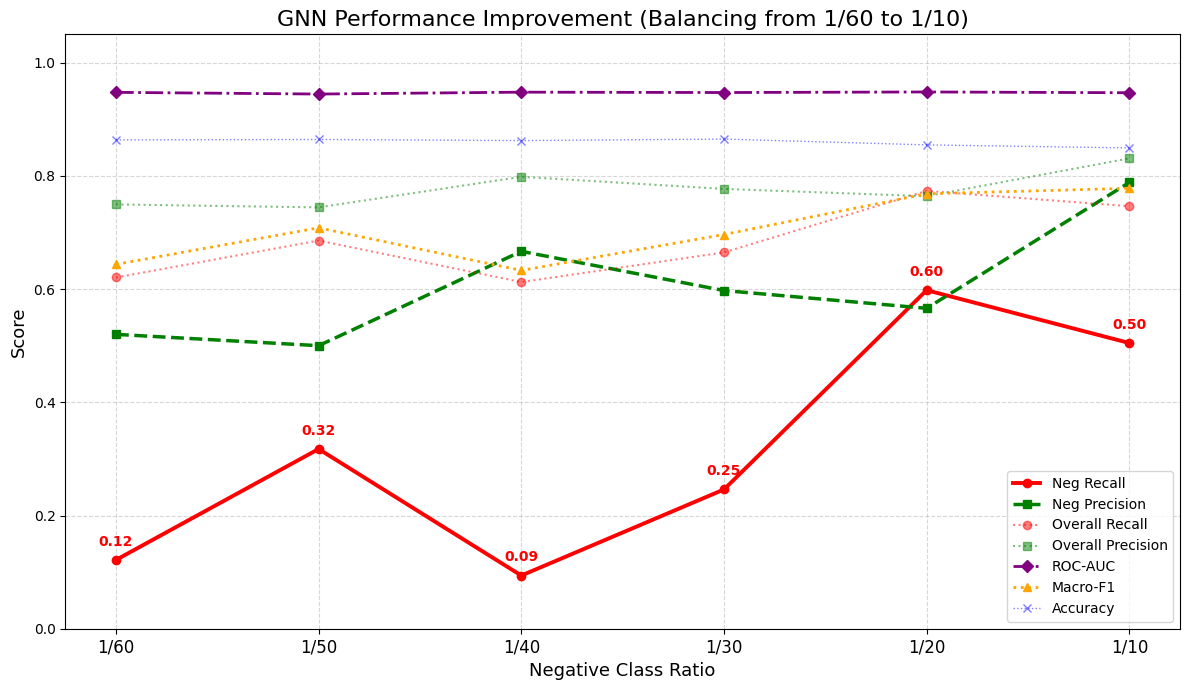

In [5]:
# Uniform test reverse
import glob
import matplotlib.pyplot as plt
from pathlib import Path

# 设置路径
data_dir = Path("/home/yyyy/codework/GARplus/GNN/code/DDA_test/data_signed/ratio_datasets")
node_csv_path = "/home/yyyy/codework/GARplus/GNN/code/DDA_test/data_signed/node_labeled.csv"
# 找到所有生成的数据集 (edges_labeled_pos10x.csv, 20x...)
# 并按倍率排序
files = sorted(data_dir.glob("edges_ratio*x.csv"), 
               key=lambda x: int(x.stem.split('ratio')[1][:-1]))

summary_results = []

print(f"找到 {len(files)} 个数据集，开始压力测试...")

for f in files:
    ratio = int(f.stem.split('ratio')[1][:-1])
    print(f"\n{'='*30}")
    print(f"正在测试倍率: {ratio}x (文件: {f.name})")
    print(f"{'='*30}")
    
    # === 调用你的训练函数 ===
    # 注意：prepare_data 会自动根据 label 1 的数量生成等量的 label 0
    # 所以这里不仅测试了 Pos 变多，也测试了 No-Edge 变多，完美符合实验设计
    model, metrics = train_model_unbalance(node_csv_path, str(f))
    
    # 记录结果：保存所有返回的指标
    summary_results.append({
        "ratio": ratio,
        "loss": metrics["loss"],
        "acc": metrics["acc"],
        "macro_f1": metrics["macro_f1"],
        "auc": metrics["auc"],
        "ap": metrics["ap"],
        "neg_recall": metrics["neg_recall"],
        "neg_precision": metrics["neg_precision"],
        "overall_rec":metrics["rec"],
        "overall_pre": metrics["pre"]
    })


import matplotlib.pyplot as plt

df = pd.DataFrame(summary_results)
print(df)
# ---------------- 计算 Increase Percent ----------------
df_10 = df[df["ratio"] == 10].iloc[0]
df_60 = df[df["ratio"] == 60].iloc[0]
exclude_cols = ["ratio"]
increase_pct = {}
for col in df.columns:
    if col not in exclude_cols:
        increase_pct[col] = (df_10[col] - df_60[col]) / df_60[col] * 100
increase_df = pd.DataFrame.from_dict(increase_pct, orient="index", columns=["increase_percent"])
increase_df = increase_df.round(2)
print(increase_df)

# ---------------- 绘图准备 ----------------
# 1. 倒序数据，使 Ratio 从 60 变到 10
summary_results_reversed = summary_results[::-1]

# 2. 生成 X 轴坐标（使用整数索引，实现均匀分布）
# 比如 6 个点，就是 [0, 1, 2, 3, 4, 5]
x_indices = np.arange(len(summary_results_reversed))

# 3. 准备 X 轴显示的标签字符串
ratios_reversed = [item['ratio'] for item in summary_results_reversed]
x_labels = [f"1/{r}" for r in ratios_reversed]

# 4. 提取 Y 轴数据
neg_recalls = [item['neg_recall'] for item in summary_results_reversed]
neg_precs   = [item['neg_precision'] for item in summary_results_reversed]
overall_recalls = [item['overall_rec'] for item in summary_results_reversed]
overall_precs   = [item['overall_pre'] for item in summary_results_reversed]
aucs = [item['auc'] for item in summary_results_reversed]
f1s  = [item['macro_f1'] for item in summary_results_reversed]
accs = [item['acc'] for item in summary_results_reversed]

# ---------------- 开始绘图 ----------------
plt.figure(figsize=(12, 7))

# Neg Recall (红色实线)
plt.plot(x_indices, neg_recalls, color='red', marker='o', linestyle='-', linewidth=2.8, label='Neg Recall')

# Neg Precision (绿色虚线)
plt.plot(x_indices, neg_precs, color='green', marker='s', linestyle='--', linewidth=2.5, label='Neg Precision')

# Overall Recall (红色点线)
plt.plot(x_indices, overall_recalls, color='red', marker='o', linestyle=':', linewidth=1.5, alpha=0.5, label='Overall Recall')

# Overall Precision (绿色点线)
plt.plot(x_indices, overall_precs, color='green', marker='s', linestyle=':', linewidth=1.5, alpha=0.5, label='Overall Precision')

# AUC (紫色点划线)
plt.plot(x_indices, aucs, color='purple', marker='D', linestyle='-.', linewidth=2, label='ROC-AUC')

# F1 (橙色点线)
plt.plot(x_indices, f1s, color='orange', marker='^', linestyle=':', linewidth=2, label='Macro-F1')

# Acc (蓝色细线)
plt.plot(x_indices, accs, color='blue', marker='x', linestyle=':', linewidth=1, alpha=0.5, label='Accuracy')

# ---------------- 装饰图表 ----------------
plt.title("GNN Performance Improvement (Balancing from 1/60 to 1/10)", fontsize=16)
plt.xlabel("Negative Class Ratio", fontsize=13)
plt.ylabel("Score", fontsize=13)
plt.ylim(0, 1.05)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10, loc='lower right')

# 【关键】将 X 轴刻度替换为字符串标签，位置使用整数索引
plt.xticks(x_indices, x_labels, fontsize=12)

# 数值标注
for x, y in zip(x_indices, neg_recalls):
    plt.text(x, y + 0.02, f"{y:.2f}", ha='center', va='bottom', fontsize=10, color='red', fontweight='bold')

# 底部箭头指示
# plt.annotate('', xy=(x_indices[-1], 0.15), xytext=(x_indices[0], 0.15),
            #  arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.5))
# plt.text(x_indices[2], 0.1, "Data becomes more balanced", ha='center')

plt.tight_layout()
plt.show()



               increase_percent
loss                      -2.05
acc                        0.16
macro_f1                  17.46
auc                        2.32
ap                        16.65
neg_recall               130.78
neg_precision             28.53
overall_rec               22.80
overall_pre                8.15


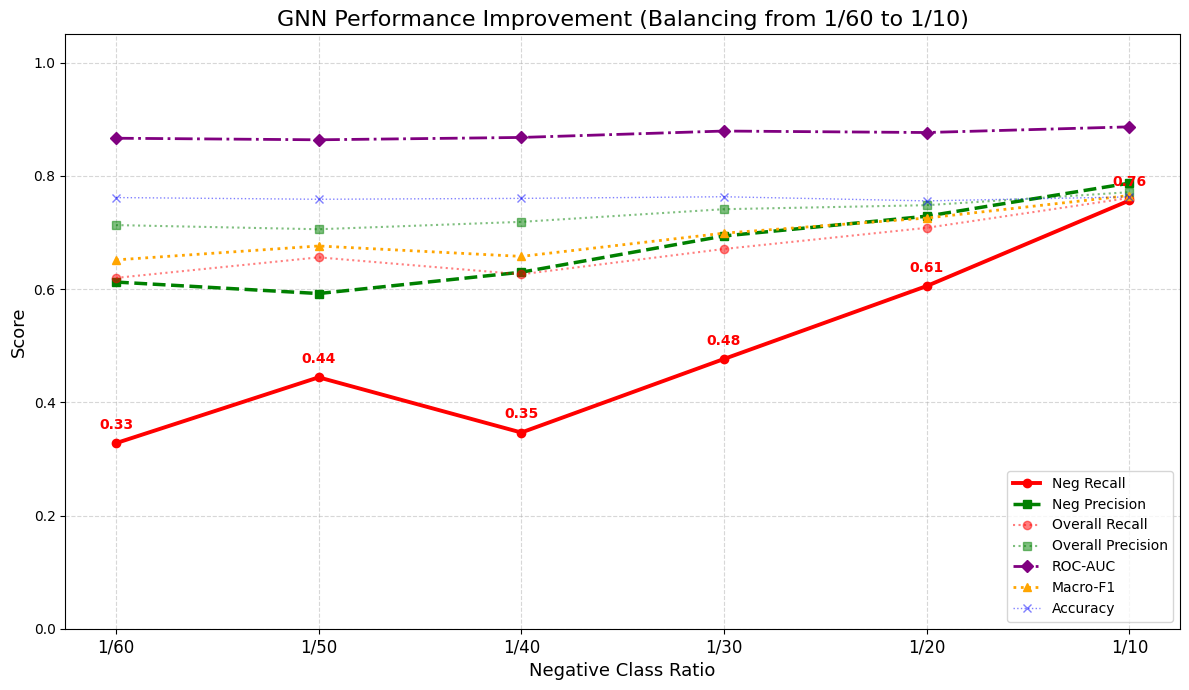

In [ ]:
df = pd.DataFrame(summary_results)

# ---------------- 计算 Increase Percent ----------------
df_10 = df[df["ratio"] == 10].iloc[0]
df_60 = df[df["ratio"] == 60].iloc[0]
exclude_cols = ["ratio"]
increase_pct = {}
for col in df.columns:
    if col not in exclude_cols:
        increase_pct[col] = (df_10[col] - df_60[col]) / df_60[col] * 100
increase_df = pd.DataFrame.from_dict(increase_pct, orient="index", columns=["increase_percent"])
increase_df = increase_df.round(2)
print(increase_df)

# ---------------- 绘图准备 ----------------
# 1. 倒序数据，使 Ratio 从 60 变到 10
summary_results_reversed = summary_results[::-1]

# 2. 生成 X 轴坐标（使用整数索引，实现均匀分布）
# 比如 6 个点，就是 [0, 1, 2, 3, 4, 5]
x_indices = np.arange(len(summary_results_reversed))

# 3. 准备 X 轴显示的标签字符串
ratios_reversed = [item['ratio'] for item in summary_results_reversed]
x_labels = [f"1/{r}" for r in ratios_reversed]

# 4. 提取 Y 轴数据
neg_recalls = [item['neg_recall'] for item in summary_results_reversed]
neg_precs   = [item['neg_precision'] for item in summary_results_reversed]
overall_recalls = [item['overall_rec'] for item in summary_results_reversed]
overall_precs   = [item['overall_pre'] for item in summary_results_reversed]
aucs = [item['auc'] for item in summary_results_reversed]
f1s  = [item['macro_f1'] for item in summary_results_reversed]
accs = [item['acc'] for item in summary_results_reversed]

# ---------------- 开始绘图 ----------------
plt.figure(figsize=(12, 7))

# Neg Recall (红色实线)
plt.plot(x_indices, neg_recalls, color='red', marker='o', linestyle='-', linewidth=2.8, label='Neg Recall')

# Neg Precision (绿色虚线)
plt.plot(x_indices, neg_precs, color='green', marker='s', linestyle='--', linewidth=2.5, label='Neg Precision')

# Overall Recall (红色点线)
plt.plot(x_indices, overall_recalls, color='red', marker='o', linestyle=':', linewidth=1.5, alpha=0.5, label='Overall Recall')

# Overall Precision (绿色点线)
plt.plot(x_indices, overall_precs, color='green', marker='s', linestyle=':', linewidth=1.5, alpha=0.5, label='Overall Precision')

# AUC (紫色点划线)
plt.plot(x_indices, aucs, color='purple', marker='D', linestyle='-.', linewidth=2, label='ROC-AUC')

# F1 (橙色点线)
plt.plot(x_indices, f1s, color='orange', marker='^', linestyle=':', linewidth=2, label='Macro-F1')

# Acc (蓝色细线)
plt.plot(x_indices, accs, color='blue', marker='x', linestyle=':', linewidth=1, alpha=0.5, label='Accuracy')

# ---------------- 装饰图表 ----------------
plt.title("GNN Performance Improvement (Balancing from 1/60 to 1/10)", fontsize=16)
plt.xlabel("Negative Class Ratio", fontsize=13)
plt.ylabel("Score", fontsize=13)
plt.ylim(0, 1.05)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10, loc='lower right')

# 【关键】将 X 轴刻度替换为字符串标签，位置使用整数索引
plt.xticks(x_indices, x_labels, fontsize=12)

# 数值标注
for x, y in zip(x_indices, neg_recalls):
    plt.text(x, y + 0.02, f"{y:.2f}", ha='center', va='bottom', fontsize=10, color='red', fontweight='bold')

# 底部箭头指示
# plt.annotate('', xy=(x_indices[-1], 0.15), xytext=(x_indices[0], 0.15),
            #  arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.5))
# plt.text(x_indices[2], 0.1, "Data becomes more balanced", ha='center')

plt.tight_layout()
plt.show()


In [4]:
print("正在处理：", "/home/yyyy/codework/GARplus/GNN/code/data_signed/edges_labeled_pos10x.csv",)
model,cur_results = train_model("/home/yyyy/codework/GARplus/GNN/code/data_signed/node_labeled.csv", "/home/yyyy/codework/GARplus/GNN/code/data_signed/edges_labeled_pos10x.csv")
print(cur_results)
print("=============================================================================")

正在处理： /home/yyyy/codework/GARplus/GNN/code/data_signed/edges_labeled_pos10x.csv
正在准备数据...
原始数据统计: Label 1 (Pos) = 68610, Label 2 (Neg) = 6861
采样后总数据量: 144081 (其中 Label 0: 68610)


Epoch 00: 100%|███████████████████████████████████| 1801/1801 [00:13<00:00, 133.82it/s, loss=0.4272]


[Epoch 00] Train Loss=922.3149 | Val Loss=75.0936 | Acc=0.7456 | Pre=0.7637 | Rec=0.6185 | F1=0.6564 | AUC=0.8665 | PRC=0.7470


Epoch 01: 100%|███████████████████████████████████| 1801/1801 [00:10<00:00, 169.35it/s, loss=0.3034]


[Epoch 01] Train Loss=716.6715 | Val Loss=73.9735 | Acc=0.7505 | Pre=0.7411 | Rec=0.7043 | F1=0.7190 | AUC=0.8770 | PRC=0.7826


...

[Epoch 17] Train Loss=357.6493 | Val Loss=93.2307 | Acc=0.7653 | Pre=0.7820 | Rec=0.7601 | F1=0.7704 | AUC=0.8878 | PRC=0.8297


Epoch 18: 100%|███████████████████████████████████| 1801/1801 [00:10<00:00, 178.51it/s, loss=0.1721]


[Epoch 18] Train Loss=351.9282 | Val Loss=95.5190 | Acc=0.7660 | Pre=0.7955 | Rec=0.7440 | F1=0.7664 | AUC=0.8886 | PRC=0.8316


Epoch 19: 100%|███████████████████████████████████| 1801/1801 [00:10<00:00, 178.30it/s, loss=0.1711]


[Epoch 19] Train Loss=340.0303 | Val Loss=96.5663 | Acc=0.7635 | Pre=0.7878 | Rec=0.7431 | F1=0.7627 | AUC=0.8901 | PRC=0.8281
训练完成！
{'train_loss': [922.3148821741343, 716.6715335249901, 648.8656533360481, 601.5824404060841, 565.9176678061485, 532.4829976707697, 509.39080810546875, 490.419195972383, 472.05554597079754, 450.944437533617, 438.17696487903595, 422.4721894823015, 411.08160880208015, 394.77440056949854, 386.8743829652667, 377.86654333397746, 365.6806435957551, 357.64927611127496, 351.92815490812063, 340.03028974309564], 'val_loss': [75.09355899691582, 73.97349977493286, 75.44738557934761, 75.61622166633606, 78.87793761491776, 78.70972192287445, 82.00759583711624, 80.52070957422256, 79.9843869805336, 82.6183333992958, 85.49815565347672, 85.8554374575615, 89.15596532821655, 88.27009731531143, 88.74221736192703, 90.46522754430771, 92.07780975103378, 93.23070067167282, 95.51897555589676, 96.56633442640305], 'prc': [0.7469533801935322, 0.7826470695845007, 0.8034700775160619, 0.80

In [5]:


if __name__ == "__main__":
    data_list = [
        "data_signed/edges_labeled_pos10x.csv",
        "data_signed/edges_labeled_pos20x.csv",
        "data_signed/edges_labeled_pos30x.csv",
        "data_signed/edges_labeled_pos40x.csv",
        "data_signed/edges_labeled_pos50x.csv",
        "data_signed/edges_labeled_pos60x.csv"
    ]


    print("正在处理：", "/home/yyyy/codework/GARplus/GNN/code/data_signed/edges_labeled_pos20x.csv",)
    model,cur_results = train_model("/home/yyyy/codework/GARplus/GNN/code/data_signed/node_labeled.csv", "/home/yyyy/codework/GARplus/GNN/code/data_signed/edges_labeled_pos20x.csv")
    print(cur_results)
    print("=============================================================================")


正在处理： /home/yyyy/codework/GARplus/GNN/code/data_signed/edges_labeled_pos20x.csv
正在准备数据...
原始数据统计: Label 1 (Pos) = 137220, Label 2 (Neg) = 6861
采样后总数据量: 281301 (其中 Label 0: 137220)


Epoch 00: 100%|███████████████████████████████████| 3517/3517 [00:19<00:00, 177.82it/s, loss=0.3153]


[Epoch 00] Train Loss=1711.7593 | Val Loss=124.8261 | Acc=0.7511 | Pre=0.7484 | Rec=0.6269 | F1=0.6596 | AUC=0.8858 | PRC=0.7462


Epoch 01: 100%|███████████████████████████████████| 3517/3517 [00:18<00:00, 186.94it/s, loss=0.4375]


[Epoch 01] Train Loss=1381.3445 | Val Loss=123.0748 | Acc=0.7666 | Pre=0.7288 | Rec=0.7177 | F1=0.7163 | AUC=0.8980 | PRC=0.7872


...

[Epoch 17] Train Loss=779.1554 | Val Loss=124.2748 | Acc=0.8082 | Pre=0.8140 | Rec=0.7423 | F1=0.7720 | AUC=0.9195 | PRC=0.8501


Epoch 18: 100%|███████████████████████████████████| 3517/3517 [00:20<00:00, 174.89it/s, loss=0.5446]


[Epoch 18] Train Loss=767.6736 | Val Loss=122.1180 | Acc=0.8085 | Pre=0.7876 | Rec=0.7807 | F1=0.7841 | AUC=0.9205 | PRC=0.8531


Epoch 19: 100%|███████████████████████████████████| 3517/3517 [00:19<00:00, 181.06it/s, loss=0.0366]


[Epoch 19] Train Loss=752.8257 | Val Loss=127.3628 | Acc=0.8086 | Pre=0.7835 | Rec=0.7819 | F1=0.7827 | AUC=0.9195 | PRC=0.8479
训练完成！
{'train_loss': [1711.7592831104994, 1381.3444641530514, 1260.9674235284328, 1174.1886989474297, 1104.4142082631588, 1056.9189109131694, 1019.2338575422764, 975.5435591265559, 947.010932661593, 916.3757611960173, 895.6490173228085, 877.3616380095482, 857.6930085793138, 837.5913139730692, 822.3895939812064, 807.8705636821687, 786.2970192320645, 779.1554270982742, 767.6736392080784, 752.8256805688143], 'val_loss': [124.826077491045, 123.07477575540543, 116.81320914626122, 118.11602288484573, 117.21211609244347, 118.70324844121933, 113.74468234181404, 116.2778197824955, 114.39393258094788, 117.05275556445122, 117.59742370247841, 120.93080291152, 117.81839713454247, 121.38172519207001, 123.2755097746849, 122.73545780777931, 121.76821854710579, 124.2747873365879, 122.11804953217506, 127.36278197169304], 'prc': [0.7461601875300455, 0.7871908646093791, 0.8140783

In [ ]:


if __name__ == "__main__":
    data_list = [
        "data_signed/edges_labeled_pos10x.csv",
        "data_signed/edges_labeled_pos20x.csv",
        "data_signed/edges_labeled_pos30x.csv",
        "data_signed/edges_labeled_pos40x.csv",
        "data_signed/edges_labeled_pos50x.csv",
        "data_signed/edges_labeled_pos60x.csv"
    ]


    print("正在处理：", "/home/yyyy/codework/GARplus/GNN/code/data_signed/edges_labeled_pos30x.csv",)
    model,cur_results = train_model("/home/yyyy/codework/GARplus/GNN/code/data_signed/node_labeled.csv", "/home/yyyy/codework/GARplus/GNN/code/data_signed/edges_labeled_pos30x.csv")
    print(cur_results)
    print("=============================================================================")


正在处理： data_signed/edges_labeled_pos30x.csv


Epoch 00: 100%|████████████████████████████████████| 5232/5232 [01:06<00:00, 78.83it/s, loss=0.6276]


[Epoch 00] Train Loss=2627.3342 | Val Loss=200.5806 | Acc=0.7142 | Pre=0.7023 | Rec=0.5562 | F1=0.5703 | AUC=0.8771 | PRC=0.6772


Epoch 01: 100%|████████████████████████████████████| 5232/5232 [01:06<00:00, 78.61it/s, loss=0.4281]


[Epoch 01] Train Loss=2305.8199 | Val Loss=206.1996 | Acc=0.7040 | Pre=0.7573 | Rec=0.5250 | F1=0.5381 | AUC=0.9005 | PRC=0.7255


...

[Epoch 17] Train Loss=1946.4851 | Val Loss=167.0090 | Acc=0.7573 | Pre=0.8275 | Rec=0.6355 | F1=0.6731 | AUC=0.9358 | PRC=0.8267


Epoch 18: 100%|████████████████████████████████████| 5232/5232 [01:09<00:00, 74.75it/s, loss=0.4389]


[Epoch 18] Train Loss=1945.7606 | Val Loss=149.9752 | Acc=0.7847 | Pre=0.8217 | Rec=0.6829 | F1=0.7173 | AUC=0.9388 | PRC=0.8374


Epoch 19: 100%|████████████████████████████████████| 5232/5232 [01:09<00:00, 75.30it/s, loss=0.3067]


[Epoch 19] Train Loss=1938.2490 | Val Loss=159.7053 | Acc=0.7678 | Pre=0.8011 | Rec=0.6930 | F1=0.7146 | AUC=0.9388 | PRC=0.8381
训练完成！
{'train_loss': [2627.3342146277428, 2305.8199160397053, 2202.609375998378, 2149.5929835885763, 2100.3714100569487, 2077.6548322439194, 2050.0164069980383, 2037.522560968995, 2018.686899870634, 2004.0976364910603, 1996.6881675124168, 1987.3615533709526, 1979.6349637806416, 1975.325053036213, 1961.767385929823, 1960.8038970828056, 1953.7665109038353, 1946.4851365089417, 1945.7605514526367, 1938.2490447461605], 'val_loss': [200.58062574267387, 206.19964519143105, 180.391145080328, 179.45515742897987, 191.85271760821342, 176.38972386717796, 174.41072168946266, 163.53587609529495, 158.89223465323448, 154.31088057160378, 158.43466904759407, 167.4288547039032, 163.9345092177391, 159.70057666301727, 158.9560373723507, 166.44297093153, 153.9991464316845, 167.00903153419495, 149.97521367669106, 159.70533934235573], 'prc': [0.6771852694355895, 0.7254643491545757, 

In [5]:


if __name__ == "__main__":
    data_list = [
        "data_signed/edges_labeled_pos10x.csv",
        "data_signed/edges_labeled_pos20x.csv",
        "data_signed/edges_labeled_pos30x.csv",
        "data_signed/edges_labeled_pos40x.csv",
        "data_signed/edges_labeled_pos50x.csv",
        "data_signed/edges_labeled_pos60x.csv"
    ]


    print("正在处理：", "data_signed/edges_labeled_pos40x.csv",)
    model,dict_imb40 = train_model("data_signed/node_labeled.csv", "data_signed/edges_labeled_pos40x.csv")
    print(dict_imb40)
    print("=============================================================================")


正在处理： data_signed/edges_labeled_pos40x.csv


Epoch 00: 100%|████████████████████████████████████| 6947/6947 [01:32<00:00, 75.24it/s, loss=0.5050]


[Epoch 00] Train Loss=3355.6639 | Val Loss=242.1718 | Acc=0.7304 | Pre=0.7929 | Rec=0.5265 | F1=0.5402 | AUC=0.8669 | PRC=0.6416


Epoch 01: 100%|████████████████████████████████████| 6947/6947 [01:33<00:00, 74.55it/s, loss=0.4309]


[Epoch 01] Train Loss=2967.2148 | Val Loss=247.1888 | Acc=0.7342 | Pre=0.7646 | Rec=0.5298 | F1=0.5432 | AUC=0.8889 | PRC=0.6626


...

[Epoch 17] Train Loss=2542.8842 | Val Loss=195.6882 | Acc=0.7881 | Pre=0.7602 | Rec=0.6922 | F1=0.7056 | AUC=0.9357 | PRC=0.8019


Epoch 18: 100%|████████████████████████████████████| 6947/6947 [01:27<00:00, 79.47it/s, loss=0.4890]


[Epoch 18] Train Loss=2529.3833 | Val Loss=218.9075 | Acc=0.7613 | Pre=0.7874 | Rec=0.6449 | F1=0.6739 | AUC=0.9340 | PRC=0.7944


Epoch 19: 100%|████████████████████████████████████| 6947/6947 [01:27<00:00, 79.60it/s, loss=0.4197]


[Epoch 19] Train Loss=2528.0625 | Val Loss=201.0152 | Acc=0.7830 | Pre=0.7721 | Rec=0.6630 | F1=0.6881 | AUC=0.9373 | PRC=0.8013
训练完成！
{'train_loss': [3355.6639197915792, 2967.2147768884897, 2857.0367852449417, 2784.725618958473, 2735.1942146122456, 2698.628760486841, 2670.108947530389, 2646.1108799278736, 2621.066817998886, 2614.8022379130125, 2601.0162702053785, 2588.4906685501337, 2580.958761483431, 2567.2822101563215, 2561.8920793011785, 2554.2887481302023, 2535.2424698770046, 2542.8842367976904, 2529.3833072185516, 2528.0624675750732], 'val_loss': [242.17179384827614, 247.18876135349274, 260.0557629466057, 243.31389689445496, 227.37123614549637, 253.08111786842346, 242.70716553926468, 211.89939600229263, 244.21291944384575, 244.94558477401733, 229.46497076749802, 210.1440567970276, 216.40422981977463, 198.3305861055851, 195.87778070569038, 210.2207261621952, 192.8082913160324, 195.68822339177132, 218.90745005011559, 201.0152454674244], 'prc': [0.6415706906082631, 0.662647557476858

In [6]:


if __name__ == "__main__":
    data_list = [
        "data_signed/edges_labeled_pos10x.csv",
        "data_signed/edges_labeled_pos20x.csv",
        "data_signed/edges_labeled_pos30x.csv",
        "data_signed/edges_labeled_pos40x.csv",
        "data_signed/edges_labeled_pos50x.csv",
        "data_signed/edges_labeled_pos60x.csv"
    ]


    print("正在处理：", "data_signed/edges_labeled_pos50x.csv",)
    model,dict_imb50 = train_model("data_signed/node_labeled.csv", "data_signed/edges_labeled_pos50x.csv")
    print(dict_imb50)
    print("=============================================================================")


正在处理： data_signed/edges_labeled_pos50x.csv


Epoch 00: 100%|████████████████████████████████████| 8662/8662 [01:53<00:00, 76.16it/s, loss=0.4797]


[Epoch 00] Train Loss=4082.5252 | Val Loss=281.3862 | Acc=0.7509 | Pre=0.8689 | Rec=0.5062 | F1=0.4990 | AUC=0.8732 | PRC=0.6582


Epoch 01: 100%|████████████████████████████████████| 8662/8662 [01:53<00:00, 76.16it/s, loss=0.3698]


[Epoch 01] Train Loss=3504.0165 | Val Loss=254.6846 | Acc=0.7798 | Pre=0.7859 | Rec=0.5925 | F1=0.6258 | AUC=0.9018 | PRC=0.7074


...

[Epoch 17] Train Loss=3081.1124 | Val Loss=241.0336 | Acc=0.7942 | Pre=0.8094 | Rec=0.6614 | F1=0.6982 | AUC=0.9370 | PRC=0.7954


Epoch 18: 100%|████████████████████████████████████| 8662/8662 [01:53<00:00, 76.59it/s, loss=0.3095]


[Epoch 18] Train Loss=3072.1780 | Val Loss=231.9538 | Acc=0.8017 | Pre=0.8266 | Rec=0.6446 | F1=0.6867 | AUC=0.9338 | PRC=0.7939


Epoch 19: 100%|████████████████████████████████████| 8662/8662 [01:53<00:00, 76.30it/s, loss=0.2436]


[Epoch 19] Train Loss=3072.8827 | Val Loss=236.0076 | Acc=0.7969 | Pre=0.8088 | Rec=0.6650 | F1=0.7017 | AUC=0.9357 | PRC=0.7977
训练完成！
{'train_loss': [4082.5251926481724, 3504.016455978155, 3372.1061646044254, 3303.0209147185087, 3257.9658253639936, 3222.351941637695, 3197.660916931927, 3181.9994995296, 3165.263869330287, 3153.463586449623, 3138.3266718685627, 3128.980640158057, 3116.4146521687508, 3102.3123228102922, 3095.579990670085, 3093.5487107634544, 3087.373052597046, 3081.1124176084995, 3072.1779734641314, 3072.8827477246523], 'val_loss': [281.3862214386463, 254.68463802337646, 272.010790258646, 251.19591853022575, 248.59842923283577, 245.05153185129166, 252.05664825439453, 260.1130701005459, 245.60779055953026, 257.74589306116104, 250.81863823533058, 250.42548578977585, 233.66066631674767, 235.72500002384186, 232.76842692494392, 243.04188591241837, 229.79121258854866, 241.0335749089718, 231.95384669303894, 236.00761878490448], 'prc': [0.6582442397548097, 0.7074228784613349, 0.

In [6]:

if __name__ == "__main__":
    data_list = [
        "data_signed/edges_labeled_pos10x.csv",
        "data_signed/edges_labeled_pos20x.csv",
        "data_signed/edges_labeled_pos30x.csv",
        "data_signed/edges_labeled_pos40x.csv",
        "data_signed/edges_labeled_pos50x.csv",
        "data_signed/edges_labeled_pos60x.csv"
    ]


    print("正在处理：", "/home/yyyy/codework/GARplus/GNN/code/data_signed/edges_labeled_pos60x.csv",)
    model,dict_imb60 = train_model("/home/yyyy/codework/GARplus/GNN/code/data_signed/node_labeled.csv", "/home/yyyy/codework/GARplus/GNN/code/data_signed/edges_labeled_pos60x.csv")
    print(dict_imb60)
    print("=============================================================================")

正在处理： /home/yyyy/codework/GARplus/GNN/code/data_signed/edges_labeled_pos60x.csv
正在准备数据...
原始数据统计: Label 1 (Pos) = 411660, Label 2 (Neg) = 6861
采样后总数据量: 830181 (其中 Label 0: 411660)


Epoch 00: 100%|█████████████████████████████████| 10378/10378 [01:04<00:00, 159.95it/s, loss=0.3996]


[Epoch 00] Train Loss=4409.2967 | Val Loss=272.4383 | Acc=0.8178 | Pre=0.8128 | Rec=0.5712 | F1=0.5870 | AUC=0.9177 | PRC=0.7358


Epoch 01: 100%|█████████████████████████████████| 10378/10378 [01:03<00:00, 163.02it/s, loss=0.4912]


[Epoch 01] Train Loss=3515.3344 | Val Loss=262.6283 | Acc=0.8227 | Pre=0.8433 | Rec=0.6376 | F1=0.6813 | AUC=0.9375 | PRC=0.8024


...

[Epoch 17] Train Loss=2468.3136 | Val Loss=219.2145 | Acc=0.8684 | Pre=0.8374 | Rec=0.7919 | F1=0.8124 | AUC=0.9561 | PRC=0.8682


Epoch 18: 100%|█████████████████████████████████| 10378/10378 [01:04<00:00, 160.76it/s, loss=0.0750]


[Epoch 18] Train Loss=2442.5811 | Val Loss=228.6118 | Acc=0.8559 | Pre=0.8373 | Rec=0.7461 | F1=0.7804 | AUC=0.9566 | PRC=0.8555


Epoch 19: 100%|█████████████████████████████████| 10378/10378 [01:05<00:00, 157.60it/s, loss=0.1377]


[Epoch 19] Train Loss=2431.6977 | Val Loss=222.6252 | Acc=0.8648 | Pre=0.8570 | Rec=0.7352 | F1=0.7784 | AUC=0.9553 | PRC=0.8569
训练完成！
{'train_loss': [4409.296732604504, 3515.3343971669674, 3261.2786596119404, 3108.026158154011, 2988.1982953101397, 2904.728580445051, 2832.1539216935635, 2781.686436660588, 2738.8327766880393, 2687.8010023236275, 2650.3974579051137, 2618.3323998227715, 2584.5369616001844, 2554.57286580652, 2525.927082821727, 2506.591127090156, 2486.3550383001566, 2468.3135578744113, 2442.5811086669564, 2431.697703398764], 'val_loss': [272.43826818466187, 262.628321737051, 239.6911818087101, 230.4518141746521, 233.2624588161707, 222.55619497597218, 220.52028138935566, 222.2287540435791, 216.91508220136166, 228.98394553363323, 222.07398454844952, 217.44248634576797, 217.27460250258446, 218.30127815902233, 218.13099485635757, 217.44995836913586, 217.71591451764107, 219.21454897522926, 228.61180675029755, 222.62519672513008], 'prc': [0.7357702649061778, 0.8024388300839549, 0

In [12]:
dict_imb10 = {'train_loss': [1021.5014381110668, 858.8988242894411, 804.2088388204575, 774.6864759325981, 757.8417594730854, 741.6388884335756, 730.7565873116255, 721.4253815859556, 714.9646542966366, 708.8106171488762, 704.363007709384, 695.9327276796103, 692.081952854991, 687.7878561764956, 684.7167649567127, 678.8916950076818, 676.0019027590752, 670.0804459899664, 671.6444116979837, 666.0418426990509], 'val_loss': [62.18393591046333, 53.697358429431915, 49.1797793507576, 50.38590911030769, 52.775708854198456, 53.79995974898338, 50.39151802659035, 51.75986164808273, 46.849339097738266, 47.70029437541962, 50.300162732601166, 48.8130721449852, 48.0139938890934, 47.58518731594086, 57.11831894516945, 46.78372973203659, 47.70887181162834, 46.37561121582985, 47.9951890707016, 46.07914978265762], 'prc': [0.7424656872669858, 0.813971868891958, 0.8373732363113399, 0.8477254308289345, 0.8548771923385412, 0.860467735472366, 0.8695275840201618, 0.8666956476859907, 0.8813963939131099, 0.8780231860610274, 0.8861399808571124, 0.8831070058386158, 0.8821016158048698, 0.8881515895798016, 0.886500548609482, 0.8910897798440619, 0.889923155586407, 0.8914224416050877, 0.8942423440236545, 0.8969604894806396], 'auc': [0.8965446720565958, 0.9216846597674514, 0.9288172056389535, 0.9318575050337108, 0.9345772059394671, 0.9365784620651937, 0.9389282687643993, 0.9409923627072688, 0.9448425342567427, 0.9428939721931989, 0.9454087045829312, 0.9450661361854359, 0.9459221780366196, 0.9449498846340857, 0.9437197793425952, 0.9481267879493309, 0.9475870755853699, 0.9492077306669676, 0.9501145835363903, 0.9507948102218854], 'f1': [0.6208430183179207, 0.7157615353047401, 0.7534168381291516, 0.756434664213847, 0.7457612818515439, 0.7381340362141859, 0.776475847778471, 0.7316058299067127, 0.7824253432972771, 0.7891507786841426, 0.7824607500363941, 0.7866654146577993, 0.7773249004668948, 0.7944819230146442, 0.7675880585198627, 0.7988240347070653, 0.7874052759298067, 0.7974827804461904, 0.7922060623526276, 0.8036873686710609]}
dict_imb20 = {'train_loss': [1877.5883109271526, 1619.2103533744812, 1528.7529337704182, 1480.0625160038471, 1456.0538122206926, 1435.445430919528, 1416.6020234972239, 1405.7856281399727, 1397.424265757203, 1387.904980942607, 1375.4977252036333, 1371.3904068171978, 1366.608160957694, 1360.1760424375534, 1358.1685782819986, 1354.1241614669561, 1343.6876981407404, 1342.8953987509012, 1334.749112740159, 1333.9158664941788], 'val_loss': [119.54184141755104, 126.18391713500023, 121.88036885857582, 117.17189458012581, 113.22032535076141, 118.89975318312645, 116.88930088281631, 113.53129038214684, 109.8750672340393, 115.82789480686188, 115.91524711251259, 115.94403970241547, 114.8860473036766, 113.39837908744812, 106.960667937994, 119.43627440929413, 118.98555785417557, 109.61650168895721, 109.84359532594681, 109.48837473988533], 'prc': [0.6783000503377755, 0.7529773215699076, 0.7933465759689732, 0.8111796597349469, 0.8220813434034864, 0.8281626113223416, 0.8287842016223768, 0.8341497785659716, 0.8362559604016083, 0.834767761078346, 0.832154731748823, 0.8488843851981658, 0.8462295249368061, 0.8521388840428537, 0.8457023694123675, 0.853980334868409, 0.853837909691762, 0.8493511621882867, 0.8563897781773782, 0.8553630990587883], 'auc': [0.8841418542766917, 0.9077288252376232, 0.9147477279965189, 0.9232541391026582, 0.9255039991077606, 0.9251706953781955, 0.9275112951554334, 0.929819568238537, 0.9303727231578202, 0.9311023284316341, 0.9303264074818333, 0.9341178007243234, 0.9351309872554844, 0.9348133414527512, 0.937289150866547, 0.9373443507519937, 0.9374822199576323, 0.9380846540821542, 0.9396993297350146, 0.9378273992590982], 'f1': [0.4989856917364443, 0.6114388818835692, 0.6765006878312221, 0.6929784477989367, 0.7091377259770827, 0.7064931890701871, 0.7082863802333064, 0.7129102138168868, 0.7053009573575114, 0.7170481433544885, 0.7104242556090727, 0.6990336628212391, 0.7036899101608695, 0.731901848422453, 0.7081293569353169, 0.7189731527412521, 0.7164460957338425, 0.7268368618243755, 0.7326479365753422, 0.7362618090023266]}
dict_imb30 = {'train_loss': [2627.3342146277428, 2305.8199160397053, 2202.609375998378, 2149.5929835885763, 2100.3714100569487, 2077.6548322439194, 2050.0164069980383, 2037.522560968995, 2018.686899870634, 2004.0976364910603, 1996.6881675124168, 1987.3615533709526, 1979.6349637806416, 1975.325053036213, 1961.767385929823, 1960.8038970828056, 1953.7665109038353, 1946.4851365089417, 1945.7605514526367, 1938.2490447461605], 'val_loss': [200.58062574267387, 206.19964519143105, 180.391145080328, 179.45515742897987, 191.85271760821342, 176.38972386717796, 174.41072168946266, 163.53587609529495, 158.89223465323448, 154.31088057160378, 158.43466904759407, 167.4288547039032, 163.9345092177391, 159.70057666301727, 158.9560373723507, 166.44297093153, 153.9991464316845, 167.00903153419495, 149.97521367669106, 159.70533934235573], 'prc': [0.6771852694355895, 0.7254643491545757, 0.7696388575508938, 0.7858157210148646, 0.7858232219968028, 0.8000151290792825, 0.805880448797731, 0.8138901079406972, 0.813937669554484, 0.8200220444087746, 0.8225835030353549, 0.8289898129495535, 0.8171985253236631, 0.8323575807452039, 0.8360569751928567, 0.8381946936235698, 0.8371336363019125, 0.8267020250139122, 0.8373912915032745, 0.838080046070632], 'auc': [0.8771460131798309, 0.900468474980679, 0.9110667955802335, 0.9156314244788629, 0.9201487099032827, 0.9253775301160729, 0.9261514833959303, 0.927791835799015, 0.9304360647000234, 0.9332742766905956, 0.933087758701815, 0.9347847537737869, 0.9320286203536327, 0.9377430420763688, 0.9379900386683052, 0.9381483128719624, 0.9383069664152776, 0.9358353247935977, 0.9387628398946748, 0.938826221824867], 'f1': [0.5702856060349577, 0.5381462756252086, 0.6274916389861257, 0.6592321398423152, 0.5981153567776372, 0.661856063048419, 0.6692769235381933, 0.692130618864596, 0.6938103491742256, 0.6942463253276198, 0.699333449657903, 0.7042539296915479, 0.6583557531504771, 0.7010244086488419, 0.7195549580120072, 0.7067964456399198, 0.7191720042674378, 0.6730729397159957, 0.717264022677766, 0.7146310561302004]}
# dict_imb40 = {'train_loss': [2888.7224815040827, 2643.346618205309, 2580.6205416321754, 2523.9436548650265, 2487.181392982602, 2459.600594982505, 2439.154680877924, 2424.824578307569, 2412.7243489176035, 2396.0795468240976, 2376.452445194125, 2361.535987585783, 2343.4935272559524, 2325.949218943715, 2311.050811931491, 2299.677842028439, 2286.880014292896, 2279.319395072758, 2270.5585660859942, 2262.9323414713144], 'val_loss': [172.30013591051102, 167.03588935732841, 162.9113792181015, 160.33617220818996, 159.4134799093008, 156.6752391308546, 157.10942436754704, 157.59894394874573, 155.78771771490574, 153.80309891700745, 153.05701476335526, 151.624218583107, 152.8735183030367, 151.09714183211327, 150.10812810063362, 148.49789489805698, 149.42810885608196, 148.51331989467144, 147.31063605844975, 147.95475874841213], 'prc': [0.695872354941894, 0.7292384096693071, 0.7384701368962766, 0.742165677716263, 0.7485824430692379, 0.7552904050332522, 0.7598434069147282, 0.7582143448021855, 0.7560283092116767, 0.7667171047450679, 0.7668741565256255, 0.770916779730017, 0.7735423454090768, 0.7674917460557144, 0.7796141287017928, 0.7858974451041875, 0.7824243113848143, 0.785611275964126, 0.7922169432896005, 0.7854731558948127], 'auc': [0.8938601762964907, 0.9069943461976728, 0.9108190352131609, 0.9141719933637953, 0.9165375220582482, 0.9189541297733315, 0.9208344657449509, 0.9199407532297541, 0.9213313692774198, 0.9248748436957869, 0.9262359669093824, 0.9275212746352057, 0.9290590021666781, 0.9281539126837796, 0.9311553113221892, 0.9322900837266926, 0.9313307691115554, 0.9336621465375067, 0.9353889954055276, 0.9333229211754653], 'f1': [0.6174914854003133, 0.6456583878908558, 0.6837782782164101, 0.7086803411982202, 0.7028171559791091, 0.7082444978079879, 0.7005404082879295, 0.6653794840373689, 0.7197876514737865, 0.6811757387613536, 0.7079225448007115, 0.7155686649785699, 0.7150742788602599, 0.727088030785073, 0.7284161741911772, 0.7171991370204237, 0.7349926883815302, 0.7324791317359759, 0.7222979903164731, 0.7353277289309602]}
# dict_imb50 = {'train_loss': [3537.8309169709682, 3274.8481382727623, 3180.7026700675488, 3121.6912850141525, 3082.1837308108807, 3053.935326576233, 3024.4820843189955, 3004.2504533976316, 2983.3000273406506, 2962.6015799045563, 2947.7789652720094, 2936.521381378174, 2924.838644295931, 2915.7991662546992, 2900.6207714676857, 2888.6125395447016, 2877.6897223219275, 2866.802934244275, 2858.4719399511814, 2849.572202153504], 'val_loss': [207.93963956832886, 199.52092257142067, 197.10343557596207, 195.1103353202343, 191.36523699760437, 188.61311456561089, 189.6190893650055, 185.80015882849693, 186.07043731212616, 186.0740061402321, 185.16281682252884, 185.84542542696, 182.84402422606945, 183.4512225985527, 183.50845181941986, 183.70767050981522, 181.06382317841053, 181.62525172531605, 182.77028684318066, 181.31068965792656], 'prc': [0.6954710524923801, 0.7309581141529025, 0.7348455852383062, 0.7491151034319653, 0.7515547465766144, 0.7654458276662749, 0.7614272040953832, 0.7687520191226044, 0.7699596670019148, 0.7671631663410449, 0.7723471012512064, 0.7745487058519669, 0.7751913433350707, 0.7780274795996153, 0.7764072681886703, 0.7758428420678634, 0.7779442631974156, 0.77996853060395, 0.7798029082631787, 0.7832660475273973], 'auc': [0.8983858352802508, 0.9078460502051776, 0.9115347003881068, 0.9127344383013914, 0.9181878529448726, 0.9205327306507858, 0.9206015389709957, 0.9243340424267493, 0.9247883339977824, 0.925355366356114, 0.9263719205134274, 0.927696434754088, 0.9285986859731934, 0.9293154598827599, 0.9298218098885457, 0.9291956353494775, 0.9311605749423423, 0.9314326025450477, 0.9309683454580763, 0.9332233630841099], 'f1': [0.6221251877514582, 0.6389072961937191, 0.7051914490590897, 0.6401603881936947, 0.7111857901390026, 0.6728548465524654, 0.6665738401187051, 0.7198801860510217, 0.7231326431342078, 0.7284912036950889, 0.6951979736479134, 0.7256272047900097, 0.7280635527686555, 0.7247538122154388, 0.7314396952390858, 0.7342406785511191, 0.7334088920403984, 0.6904320300381565, 0.7330147629593696, 0.7302461536953282]}
# dict_imb60 ={'train_loss': [4183.67197740078, 3883.1144286692142, 3811.2266265153885, 3754.560053884983, 3710.3762929439545, 3669.1832610815763, 3639.9832013994455, 3605.637096181512, 3579.221229739487, 3557.7652866095304, 3537.0565503910184, 3519.8286170959473, 3506.1457823067904, 3490.8157343268394, 3476.9158235639334, 3463.686419710517, 3454.270641490817, 3441.128832742572, 3429.3257678076625, 3420.5781932622194], 'val_loss': [250.22983992099762, 239.84954172372818, 236.89440056681633, 234.33000427484512, 233.9876367598772, 231.11823642253876, 229.3301856070757, 227.41550958156586, 230.035381346941, 226.87125000357628, 222.98087012767792, 222.58405700325966, 223.20345851778984, 223.7851179242134, 219.2671072334051, 217.06723895668983, 218.41490553319454, 218.35604225099087, 220.95187897980213, 218.52301354706287], 'prc': [0.7041608357678958, 0.7356972257372568, 0.7392838279666697, 0.7455292665005389, 0.7455342010835752, 0.7607282901791184, 0.7653688121554098, 0.7664494008977067, 0.7665959063463751, 0.771537451132209, 0.7739476650356053, 0.7832522707756696, 0.7774556241939338, 0.778835895052869, 0.7854255092819414, 0.7894363453649458, 0.7857406327740701, 0.7844608057394383, 0.7539196092961186, 0.7849145734380601], 'auc': [0.9005220011448253, 0.9117633593533282, 0.9170794482775252, 0.920340531783927, 0.9206364131239503, 0.9266308027027123, 0.9270898499746753, 0.9294079934946989, 0.9289561618769765, 0.9311813110648565, 0.932371470782869, 0.9332701098075776, 0.9333798401717021, 0.9345939343578366, 0.9353718922577924, 0.9379141857980217, 0.9356019104116617, 0.9367187496917534, 0.9343841131783378, 0.9369748771734897], 'f1': [0.561174107609752, 0.6318979384133548, 0.6786248550029074, 0.6305316759748051, 0.5907652866128191, 0.6963638227777204, 0.6697250321798346, 0.6340544715568187, 0.6546267538709448, 0.7246219015102988, 0.6821424955502615, 0.6836756534722617, 0.7326193990848434, 0.7381826656153931, 0.6975039540999334, 0.7133178940198409, 0.6946739012319738, 0.7248656508039272, 0.6996531948857774, 0.6824388249051893]}

In [13]:
print(dict_imb60)

{'train_loss': [4661.000874042511, 4121.102180808783, 3971.0364537090063, 3885.988481923938, 3822.7264528125525, 3784.2074640244246, 3740.047464236617, 3708.658115670085, 3689.0344011187553, 3676.3574073165655, 3659.047667220235, 3643.772821098566, 3637.362204000354, 3628.3457558602095, 3617.098372682929, 3606.134112790227, 3598.646329678595, 3594.9425439983606, 3587.2707431465387, 3579.0261850729585], 'val_loss': [319.9076750576496, 330.2598112523556, 319.74279552698135, 310.9854253232479, 317.6853936612606, 307.59848111867905, 274.1135968565941, 262.3671116232872, 268.5834243297577, 274.2485408782959, 274.6723628938198, 273.86663272976875, 259.6252816617489, 252.8621783554554, 269.6751181483269, 266.6423372924328, 249.26907724142075, 255.94924691319466, 257.28414312005043, 248.7836087346077], 'prc': [0.6172449662165743, 0.6404869024244271, 0.6658439776646595, 0.6707129394208377, 0.7037161117037344, 0.7170261601022968, 0.7478686544398916, 0.7478922069336891, 0.7120057449268465, 0.7529

=== Final metrics (last epoch) and drop% vs baseline ===
imbalance	auc_final	prc_final	f1_final	auc_drop%	prc_drop%	f1_drop%
10	0.950795	0.896960	0.803687	0.00	0.00	0.00
20	0.937827	0.855363	0.736262	1.36	4.64	8.39
30	0.938826	0.838080	0.714631	1.26	6.56	11.08
40	0.933323	0.785473	0.735328	1.84	12.43	8.51
50	0.933223	0.783266	0.730246	1.85	12.68	9.14
60	0.938133	0.760430	0.645586	1.33	15.22	19.67


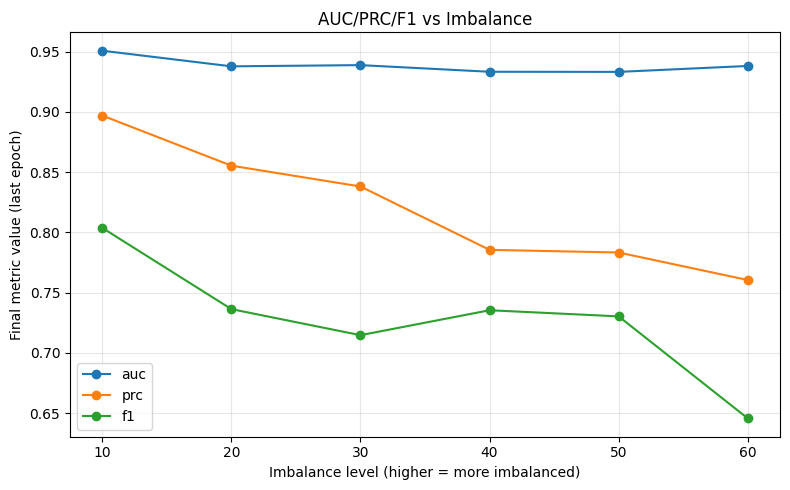

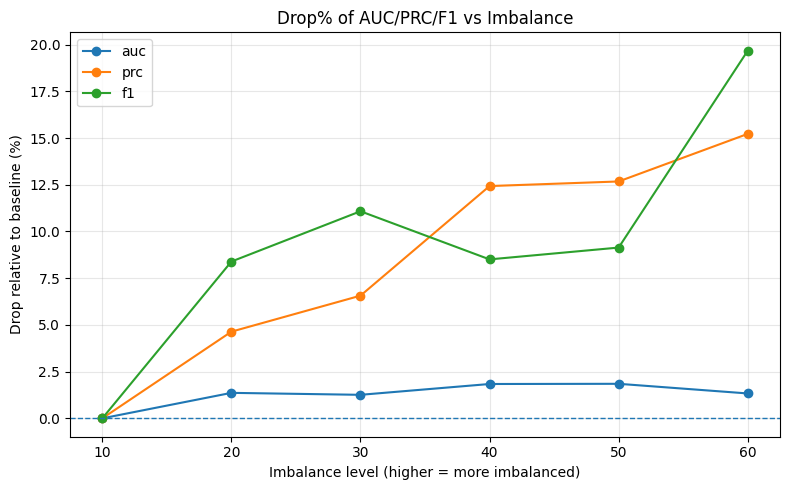

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def summarize_last_metrics(all_results, metrics=None):
    """
    all_results: list of dict, each dict like:
        {
          'train_loss': [...], 'val_loss': [...], 'auc': [...], 'prc': [...], 'f1': [...]
        }
    metrics: list of metric names you want to track. If None, auto-detect common ones.
    return:
        last_vals: dict(metric -> np.array shape [n_runs])
    """
    if metrics is None:
        # 自动从第一组里找指标 key
        metrics = list(all_results[0].keys())

    n = len(all_results)
    last_vals = {m: np.zeros(n, dtype=float) for m in metrics}

    for i, res in enumerate(all_results):
        for m in metrics:
            if m not in res:
                raise KeyError(f"Metric '{m}' not found in run {i}.")
            if len(res[m]) == 0:
                raise ValueError(f"Metric '{m}' list is empty in run {i}.")
            last_vals[m][i] = float(res[m][-1])  # 取最后一个

    return last_vals

def percent_drop(last_vals, baseline_idx=0):
    """
    last_vals: dict(metric -> np.array)
    baseline_idx: which run to treat as baseline (most balanced)
    return:
        drops: dict(metric -> np.array)  # drop% relative to baseline
    """
    drops = {}
    for m, arr in last_vals.items():
        base = arr[baseline_idx]
        # 防止 base=0
        if np.isclose(base, 0):
            drops[m] = np.full_like(arr, np.nan)
        else:
            drops[m] = (base - arr) / base * 100.0
    return drops

def plot_metrics_vs_imbalance(imbalance_levels, last_vals, metrics_to_plot=None, 
                             title="Metrics vs Imbalance"):
    """
    imbalance_levels: list/np.array length n_runs, x-axis
    last_vals: dict(metric -> np.array)
    metrics_to_plot: choose subset to plot; None means plot all
    """
    x = np.array(imbalance_levels, dtype=float)
    if metrics_to_plot is None:
        metrics_to_plot = list(last_vals.keys())

    plt.figure(figsize=(8,5))
    for m in metrics_to_plot:
        y = last_vals[m]
        plt.plot(x, y, marker='o', label=m)

    plt.xlabel("Imbalance level (higher = more imbalanced)")
    plt.ylabel("Final metric value (last epoch)")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_drop_vs_imbalance(imbalance_levels, drops, metrics_to_plot=None,
                           title="Percent drop vs Imbalance"):
    x = np.array(imbalance_levels, dtype=float)
    if metrics_to_plot is None:
        metrics_to_plot = list(drops.keys())

    plt.figure(figsize=(8,5))
    for m in metrics_to_plot:
        y = drops[m]
        plt.plot(x, y, marker='o', label=m)

    plt.xlabel("Imbalance level (higher = more imbalanced)")
    plt.ylabel("Drop relative to baseline (%)")
    plt.title(title)
    plt.axhline(0, linestyle='--', linewidth=1)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def print_summary_table(imbalance_levels, last_vals, drops, metrics=None):
    if metrics is None:
        metrics = list(last_vals.keys())

    print("=== Final metrics (last epoch) and drop% vs baseline ===")
    header = ["imbalance"] + [f"{m}_final" for m in metrics] + [f"{m}_drop%" for m in metrics]
    print("\t".join(header))

    for i, lvl in enumerate(imbalance_levels):
        row = [str(lvl)]
        row += [f"{last_vals[m][i]:.6f}" for m in metrics]
        row += [("nan" if np.isnan(drops[m][i]) else f"{drops[m][i]:.2f}") for m in metrics]
        print("\t".join(row))


# ==========================
# 你需要改的只有这里
# ==========================

# imbalance_levels: 每组结果对应的不平衡程度（你自己定义）
# 例子：正负样本比 1:1, 1:5, 1:10, 1:20 ...
imbalance_levels = [10, 20, 30, 40,50,60]  # <-- 改成你的

# all_results: 多组训练结果，每组一个 dict
# 下面只放了一个示例，你要把你的多组 dict 都塞进 list
all_results = [
    dict_imb10,
dict_imb20,
dict_imb30,
dict_imb40,
dict_imb50,
dict_imb60
]

# 你想画哪些指标（默认是 all_results[0] 里出现的全部 key）
metrics = ['auc', 'prc', 'f1']  # <-- 想加 val_loss/train_loss 也可以放进来

# ==========================
# 跑起来
# ==========================

last_vals = summarize_last_metrics(all_results, metrics=metrics)
drops = percent_drop(last_vals, baseline_idx=0)

print_summary_table(imbalance_levels, last_vals, drops, metrics=metrics)

plot_metrics_vs_imbalance(
    imbalance_levels, last_vals, metrics_to_plot=metrics,
    title="AUC/PRC/F1 vs Imbalance"
)

plot_drop_vs_imbalance(
    imbalance_levels, drops, metrics_to_plot=metrics,
    title="Drop% of AUC/PRC/F1 vs Imbalance"
)
